# PREVISIONE QUALITÀ DELL'ARIA
Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## 1. Introduzione

### 1.1 Obiettivo

L'obiettivo di questo progetto è di prevedere la concentrazione oraria di **PM2.5** (µg/m³) nell'area metropolitana di Pechino a partire da variabili meteorologiche, temporali e altri inquinanti atmosferici.

Il PM2.5 è particolato fine con diametro inferiore a 2.5 µm, abbastanza piccolo da penetrare nei polmoni e nel sangue. L'OMS raccomanda un limite di 15 µg/m³ per la media giornaliera. Pechino nel periodo 2013–2017 superava regolarmente questa soglia, con picchi oltre i 500 µg/m³.

Un modello accurato di previsione del PM2.5 ha applicazioni concrete: sistemi di allerta precoce per la popolazione, supporto alla pianificazione di politiche ambientali, e valutazione della possibilità di stimare l'inquinamento usando solo dati meteo.

Questo tema è rilevante anche nel contesto italiano: la Pianura Padana è tra le zone peggiori d'Europa per PM2.5.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

SEED = 42

### 1.2 Importazione del dataset

I dataset utilizzati sono stati ottenuti da [**Beijing Multi-Site Air-Quality Data**](https://doi.org/10.24432/C5RK5G). Contengono misurazioni orarie da 12 stazioni di monitoraggio di Pechino nel periodo marzo 2013 – febbraio 2017.

Le feature si suddividono in quattro categorie:

**Temporali:** `year`, `month`, `day`, `hour`.

**Inquinanti** (µg/m³):
- `PM2.5`: particolato fine, target della previsione
- `PM10`: particolato grossolano, spesso co-emesso con il PM2.5
- `SO2`: biossido di zolfo, da combustione di carbone
- `NO2`: biossido di azoto, da traffico e centrali termiche
- `CO`: monossido di carbonio, indicatore di combustione incompleta
- `O3`: ozono, inquinante secondario con comportamento opposto agli altri (alto quando PM2.5 è basso)

**Meteorologiche:**
- `TEMP` (°C): temperatura dell'aria, influenza la stabilità atmosferica e la dispersione degli inquinanti
- `PRES` (hPa): pressione atmosferica, valori alti indicano aria stagnante che favorisce l'accumulo del particolato
- `DEWP` (°C): temperatura del punto di rugiada, misura l'umidità dell'aria; valori alti indicano aria umida che può favorire la formazione di particolato secondario
- `RAIN` (mm): precipitazioni, la pioggia lava il particolato dall'atmosfera riducendo il PM2.5
- `WSPM` (m/s): velocità del vento, venti forti disperdono gli inquinanti riducendo la concentrazione locale
- `wd`: direzione del vento (categorica), determina la provenienza delle masse d'aria e quindi il trasporto di inquinanti da aree industriali o rurali

**Metadati:** `station`: nome della stazione di monitoraggio.

In [2]:
directory = "datasets"
dfs = []
for nome_file in os.listdir(directory):
    if nome_file.endswith(".csv"):
        dfs.append(pd.read_csv(os.path.join(directory, nome_file), index_col=False))

df = pd.concat(dfs, ignore_index=True)

if 'No' in df.columns:
    df = df.drop(columns=['No'])

df.info(verbose=False, memory_usage='deep')
df.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Columns: 17 entries, year to station
dtypes: float64(11), int64(4), object(2)
memory usage: 98.1 MB


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013,3,1,0,5.0,14.0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Nongzhanguan
1,2013,3,1,1,8.0,12.0,6.0,14.0,200.0,84.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Nongzhanguan
2,2013,3,1,2,3.0,6.0,5.0,14.0,200.0,83.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Nongzhanguan


La colonna `No` (identificatore) viene rimossa in fase di caricamento poiché non informativa.

## 2. Analisi esplorativa dei dati

### 2.1 Statistiche generali

In [3]:
df.describe().round(2)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.00,420768.00,420768.00,420768.00,412029.00,414319.00,411747.00,408652.00,400067.00,407491.00,420370.00,420375.00,420365.00,420378.00,420450.00
mean,2014.66,6.52,15.73,11.50,79.79,104.60,15.83,50.64,1230.77,57.37,13.54,1010.75,2.49,0.06,1.73
std,1.18,3.45,8.80,6.92,80.82,91.77,21.65,35.13,1160.18,56.66,11.44,10.47,13.79,0.82,1.25
min,2013.00,1.00,1.00,0.00,2.00,2.00,0.29,1.03,100.00,0.21,-19.90,982.40,-43.40,0.00,0.00
25%,2014.00,4.00,8.00,5.75,20.00,36.00,3.00,23.00,500.00,11.00,3.10,1002.30,-8.90,0.00,0.90
50%,2015.00,7.00,16.00,11.50,55.00,82.00,7.00,43.00,900.00,45.00,14.50,1010.40,3.10,0.00,1.40
75%,2016.00,10.00,23.00,17.25,111.00,145.00,20.00,71.00,1500.00,82.00,23.30,1019.00,15.10,0.00,2.20
max,2017.00,12.00,31.00,23.00,999.00,999.00,500.00,290.00,10000.00,1071.00,41.60,1042.80,29.10,72.50,13.20


Il PM2.5 medio è circa 80 µg/m³ con distribuzione molto dispera (deviazione standard di circa 80). Il massimo raggiunge 999 µg/m³, un valore estremo che potrebbe indicare un evento eccezionale o un'anomalia del sensore. Gli altri inquinanti (PM10, SO2, NO2, CO) mostrano un pattern simile. Le variabili meteorologiche hanno range coerenti con il clima di Pechino.

In [4]:
nan_counts = df.isnull().sum()
nan_percentages = (nan_counts / len(df) * 100).round(2)

nan_summary = pd.DataFrame({
    '# NaN': nan_counts,
    '% NaN': nan_percentages
}).sort_values('% NaN', ascending=False)

nan_summary = nan_summary[nan_summary['# NaN'] > 0]
nan_summary

,# NaN,% NaN
CO,20701,4.92
O3,13277,3.16
NO2,12116,2.88
SO2,9021,2.14
PM2.5,8739,2.08
PM10,6449,1.53
wd,1822,0.43
DEWP,403,0.10
RAIN,390,0.09
TEMP,398,0.09


Si osserva che le variabili temporali (`year`, `month`, `day`, `hour`) e station non hanno valori mancanti.
Gli inquinanti, invece, presentano la percentuale più alta di NaN, dovuta probabilmente a malfunzionamenti dei sensori.
Le variabili meteorologiche (`TEMP`, `PRES`, `DEWP`, `RAIN` e `WSPM`) sono quasi complete.

La percentuale di NaN rimane comunque contenuta per tutte le colonne, rendendo il dataset complessivamente affidabile. I valori mancanti verranno gestiti nella fase di preparazione dei dati (sezione 3).

### 2.2 Distribuzione del target (PM2.5)

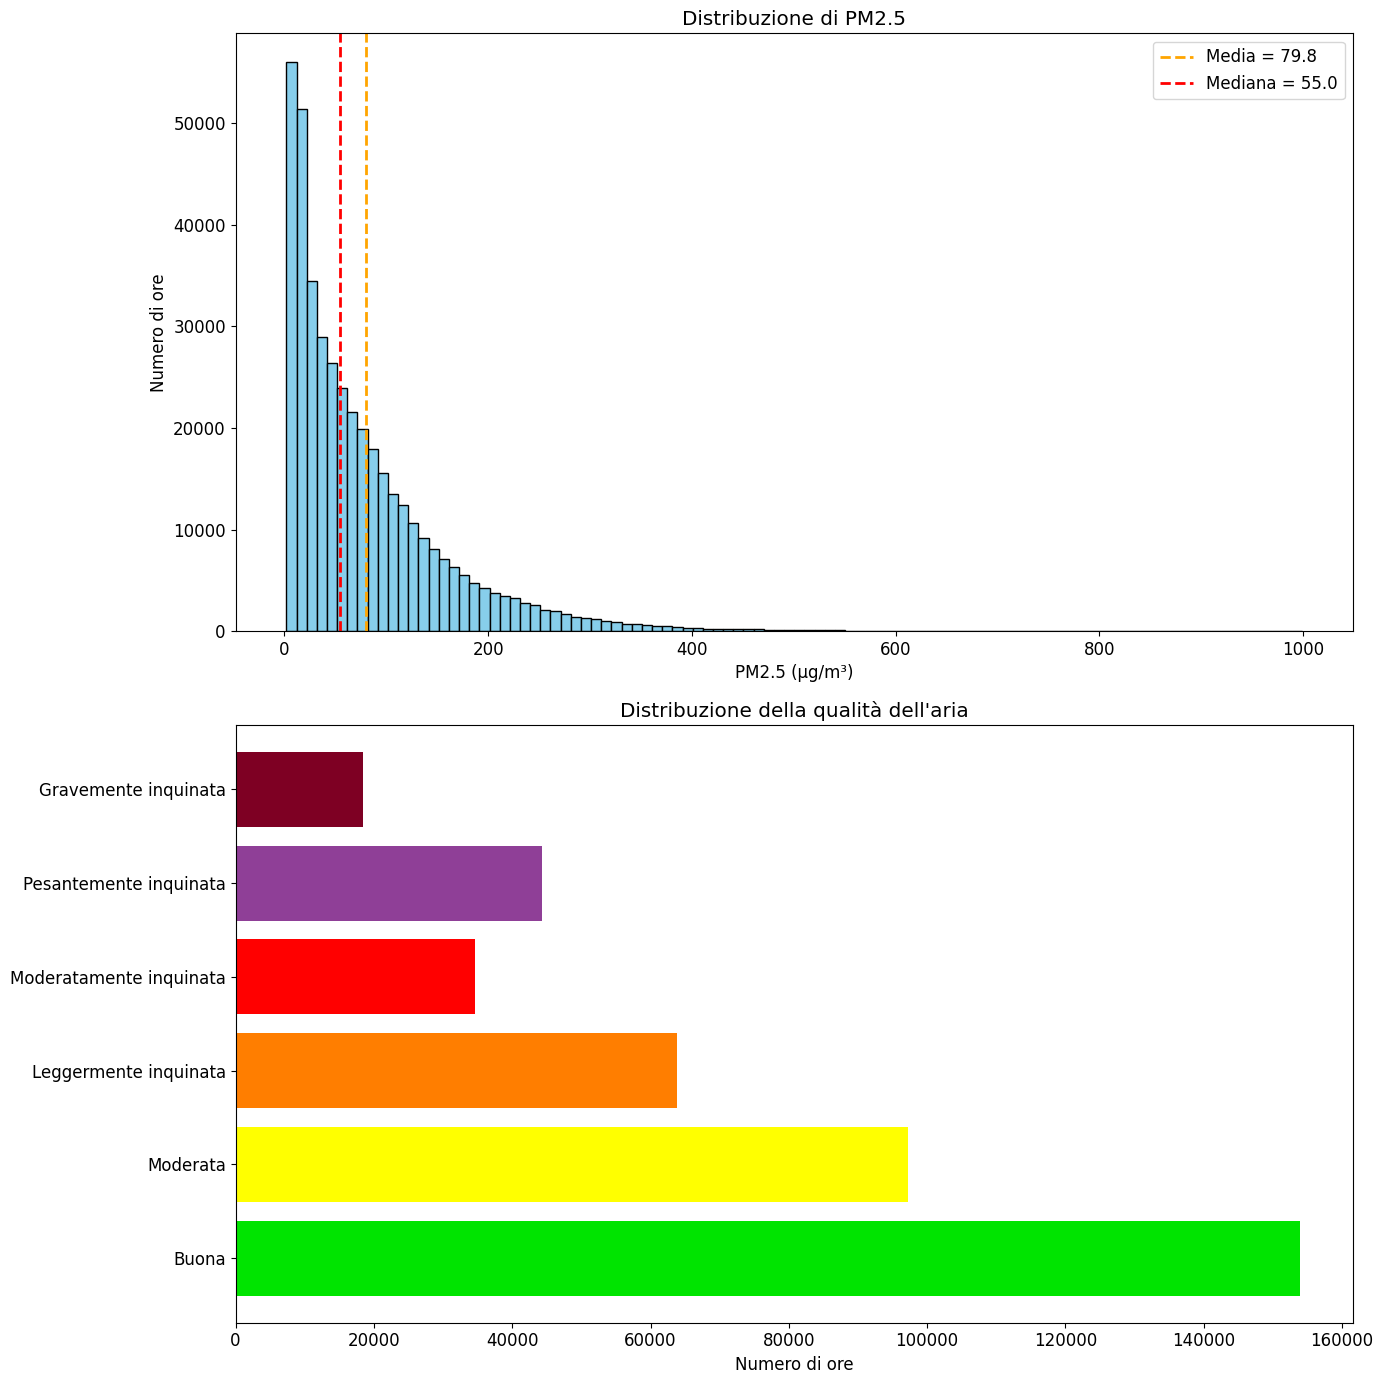

Media: 79.8 µg/m³
Mediana: 55.0 µg/m³
Std: 80.8
Min: 2
Max: 999
Ore con aria buona (≤35): 37.3%
Ore con aria insalubre (>115): 23.6%


In [5]:
pm25 = df['PM2.5'].dropna()

mean_val = pm25.mean()
median_val = pm25.median()

# Fasce di qualità dell'aria
aqi_labels = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]

aqi_cat = pd.cut(pm25, bins=aqi_bins, labels=aqi_labels, include_lowest=True)
aqi_counts = aqi_cat.value_counts().reindex(aqi_labels)

# Figura
fig, axes = plt.subplots(2, 1, figsize=(14, 14))

# Istogramma
axes[0].hist(pm25, bins=100, color='skyblue', edgecolor='black')
axes[0].axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Media = {mean_val:.1f}')
axes[0].axvline(median_val, color='red', linestyle='--', linewidth=2, label=f'Mediana = {median_val:.1f}')
axes[0].set_title('Distribuzione di PM2.5')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Numero di ore')
axes[0].legend()

# Categorie AQI
axes[1].barh(aqi_counts.index, aqi_counts.values, color=aqi_colors)
axes[1].set_title("Distribuzione della qualità dell'aria")
axes[1].set_xlabel('Numero di ore')

# Statistiche
percentuale_buona = (pm25 <= 35).sum() / len(pm25) * 100
percentuale_insalubre = (pm25 > 115).sum() / len(pm25) * 100

plt.tight_layout()
plt.show()

print(f"Media: {mean_val:.1f} µg/m³\nMediana: {median_val:.1f} µg/m³")
print(f"Std: {pm25.std():.1f}")
print(f"Min: {pm25.min():.0f}\nMax: {pm25.max():.0f}")
print(f"Ore con aria buona (≤35): {percentuale_buona:.1f}%")
print(f"Ore con aria insalubre (>115): {percentuale_insalubre:.1f}%")

La distribuzione del `PM2.5` è asimmetrica: la maggior parte delle ore ha valori tra 0 e 100 µg/m³, ma ci sono picchi che superano i 500 µg/m³. Solo il 37% delle ore ha aria "buona" (≤35 µg/m³), mentre il 23.6% rientra nelle categorie con livelli dannosi.

### 2.3 Analisi temporale

Creazione di un'unica colonna `datetime` a partire dalle variabili temporali separate, da cui si estrae il giorno della settimana `weekday` (0 = lunedì, 6 = domenica).

In [6]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df['weekday'] = df['datetime'].dt.dayofweek

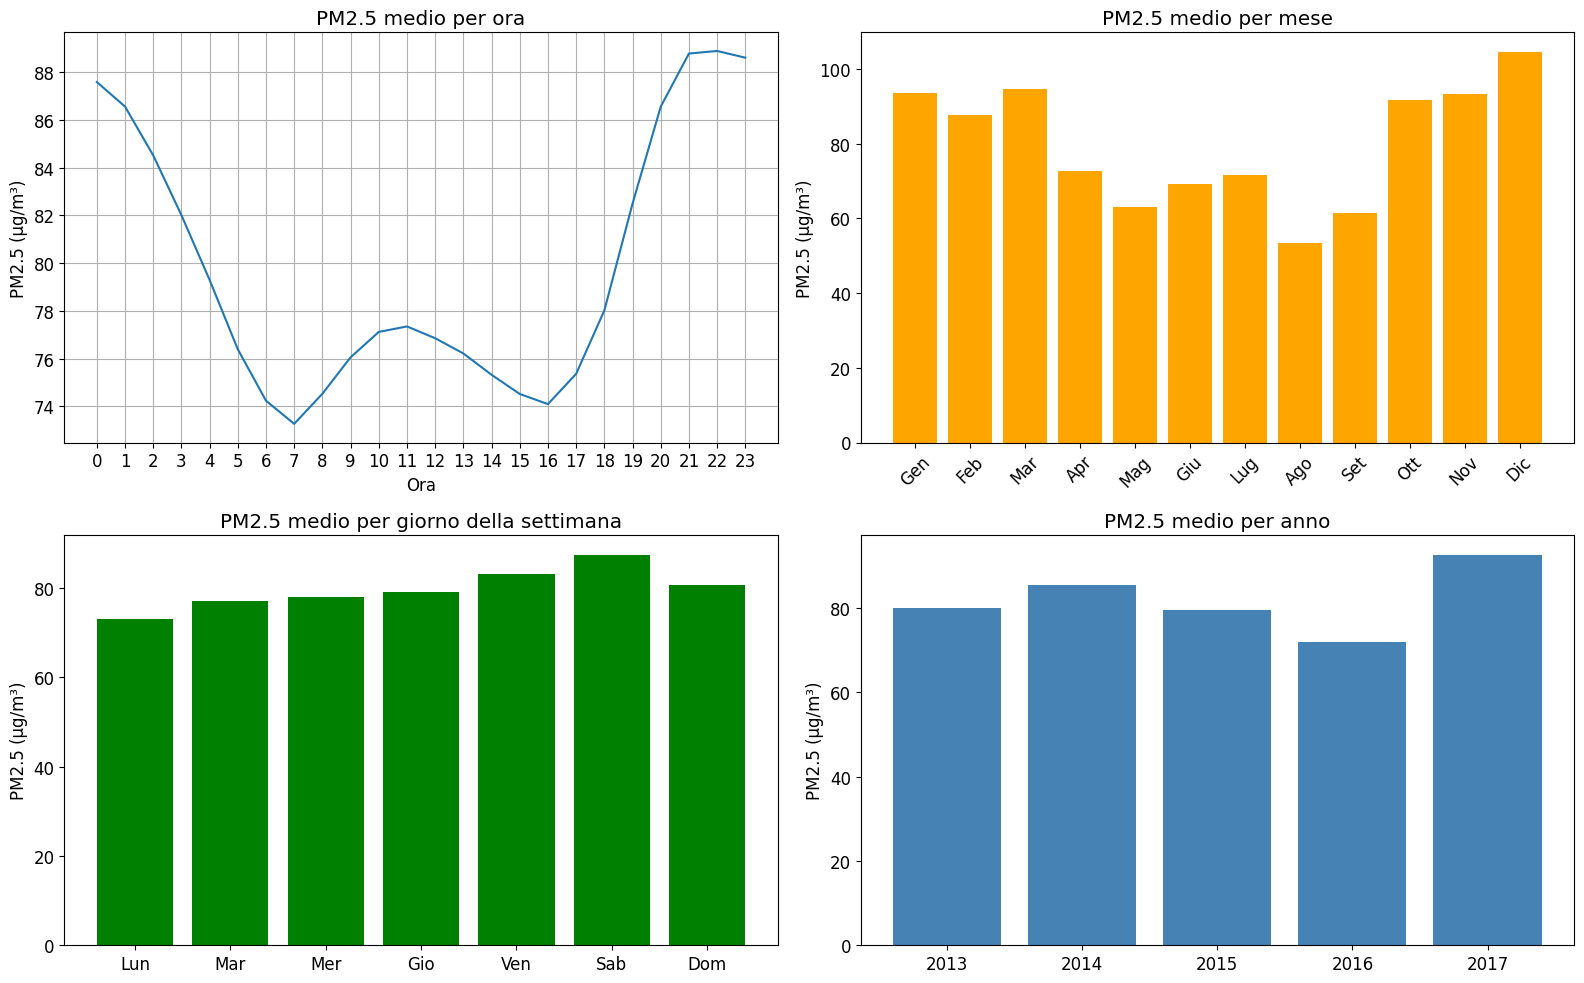

In [7]:
hourly_pm25 = df.groupby('hour')['PM2.5'].mean()
monthly_pm25 = df.groupby('month')['PM2.5'].mean()

mesi = ['Gen', 'Feb', 'Mar', 'Apr', 'Mag', 'Giu', 'Lug', 'Ago', 'Set', 'Ott', 'Nov', 'Dic']

weekday_map = {0:'Lun', 1:'Mar', 2:'Mer', 3:'Gio', 4:'Ven', 5:'Sab', 6:'Dom'}
weekday_pm25 = df.groupby('weekday')['PM2.5'].mean().rename(index=weekday_map)

yearly_pm25 = df.groupby('year')['PM2.5'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Orario
axes[0,0].plot(hourly_pm25.index, hourly_pm25.values)
axes[0,0].set_title('PM2.5 medio per ora')
axes[0,0].set_xlabel('Ora')
axes[0,0].set_ylabel('PM2.5 (µg/m³)')
axes[0,0].set_xticks(range(24))
axes[0,0].grid(True)

# Mensile
axes[0,1].bar(mesi, monthly_pm25.values, color='orange')
axes[0,1].set_title('PM2.5 medio per mese')
axes[0,1].set_ylabel('PM2.5 (µg/m³)')
axes[0,1].tick_params(axis='x', rotation=45)

# Settimanale
axes[1,0].bar(weekday_pm25.index, weekday_pm25.values, color='green')
axes[1,0].set_title('PM2.5 medio per giorno della settimana')
axes[1,0].set_ylabel('PM2.5 (µg/m³)')

# Annuale
axes[1,1].bar(yearly_pm25.index.astype(str), yearly_pm25.values, color='steelblue')
axes[1,1].set_title('PM2.5 medio per anno')
axes[1,1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

**Orario**: i livelli massimi si registrano durante la notte (18:00–04:00), con un minimo la mattina (6:00–08:00) e nel primo pomeriggio (14:00–17:00).

**Stagionale**: i mesi invernali mostrano valori molto più alti dell'estate.

**Settimanale**: le differenze tra giorni feriali e weekend sono minime. Questo indica che il traffico veicolare non è la causa principale del PM2.5.

**Annuale**: si osserva un lieve miglioramento nel tempo, con l'eccezione del 2017.

### 2.4 PM2.5 medio per ora e mese

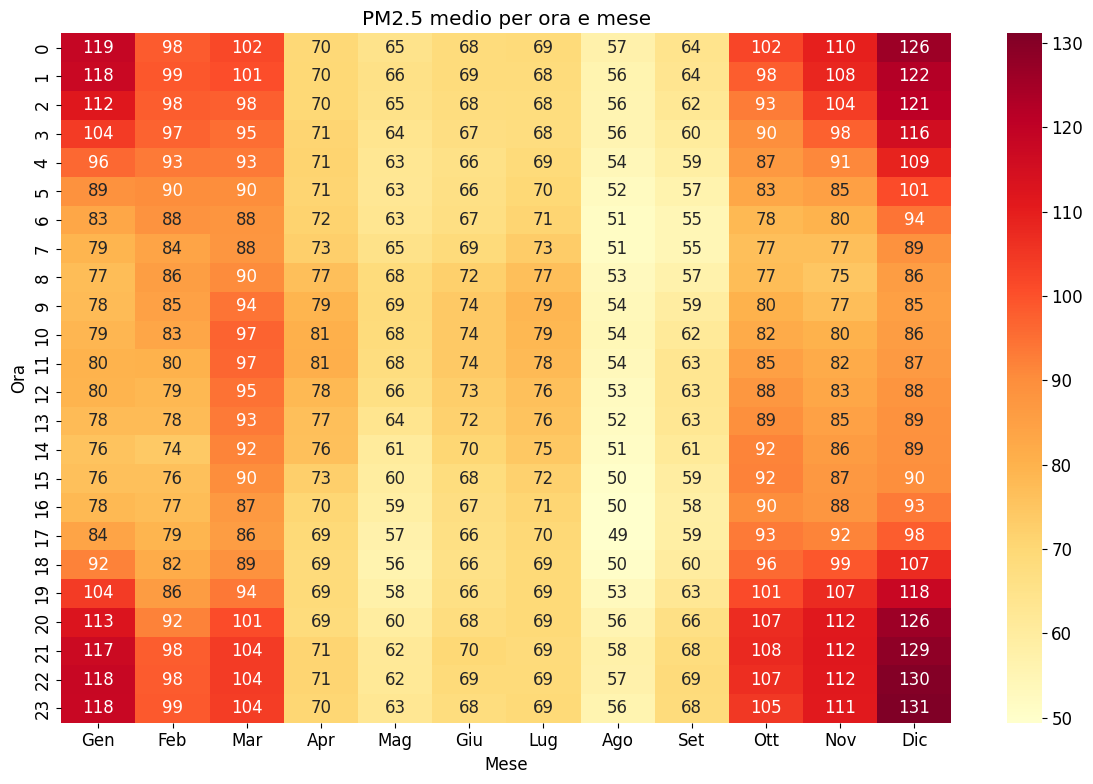

In [8]:
pivot = df.pivot_table(
    values='PM2.5',
    index='hour',
    columns='month',
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', xticklabels=mesi, yticklabels=range(24))
plt.title('PM2.5 medio per ora e mese')
plt.xlabel('Mese')
plt.ylabel('Ora')
plt.tight_layout()
plt.show()

I mesi invernali (novembre–febbraio) mostrano i valori più elevati in tutte le fasce orarie, a causa principalmente del riscaldamento domestico, mentre i mesi estivi (giugno–agosto) presentano i valori più bassi.

Giornalmente si osserva un picco serale/notturno (tra le 18:00 e le 04:00) e un minimo nel primo pomeriggio (13:00–16:00). I momenti peggiori sono quindi le ore notturne nei mesi invernali.

### 2.5 Distribuzione variabili meteorologiche

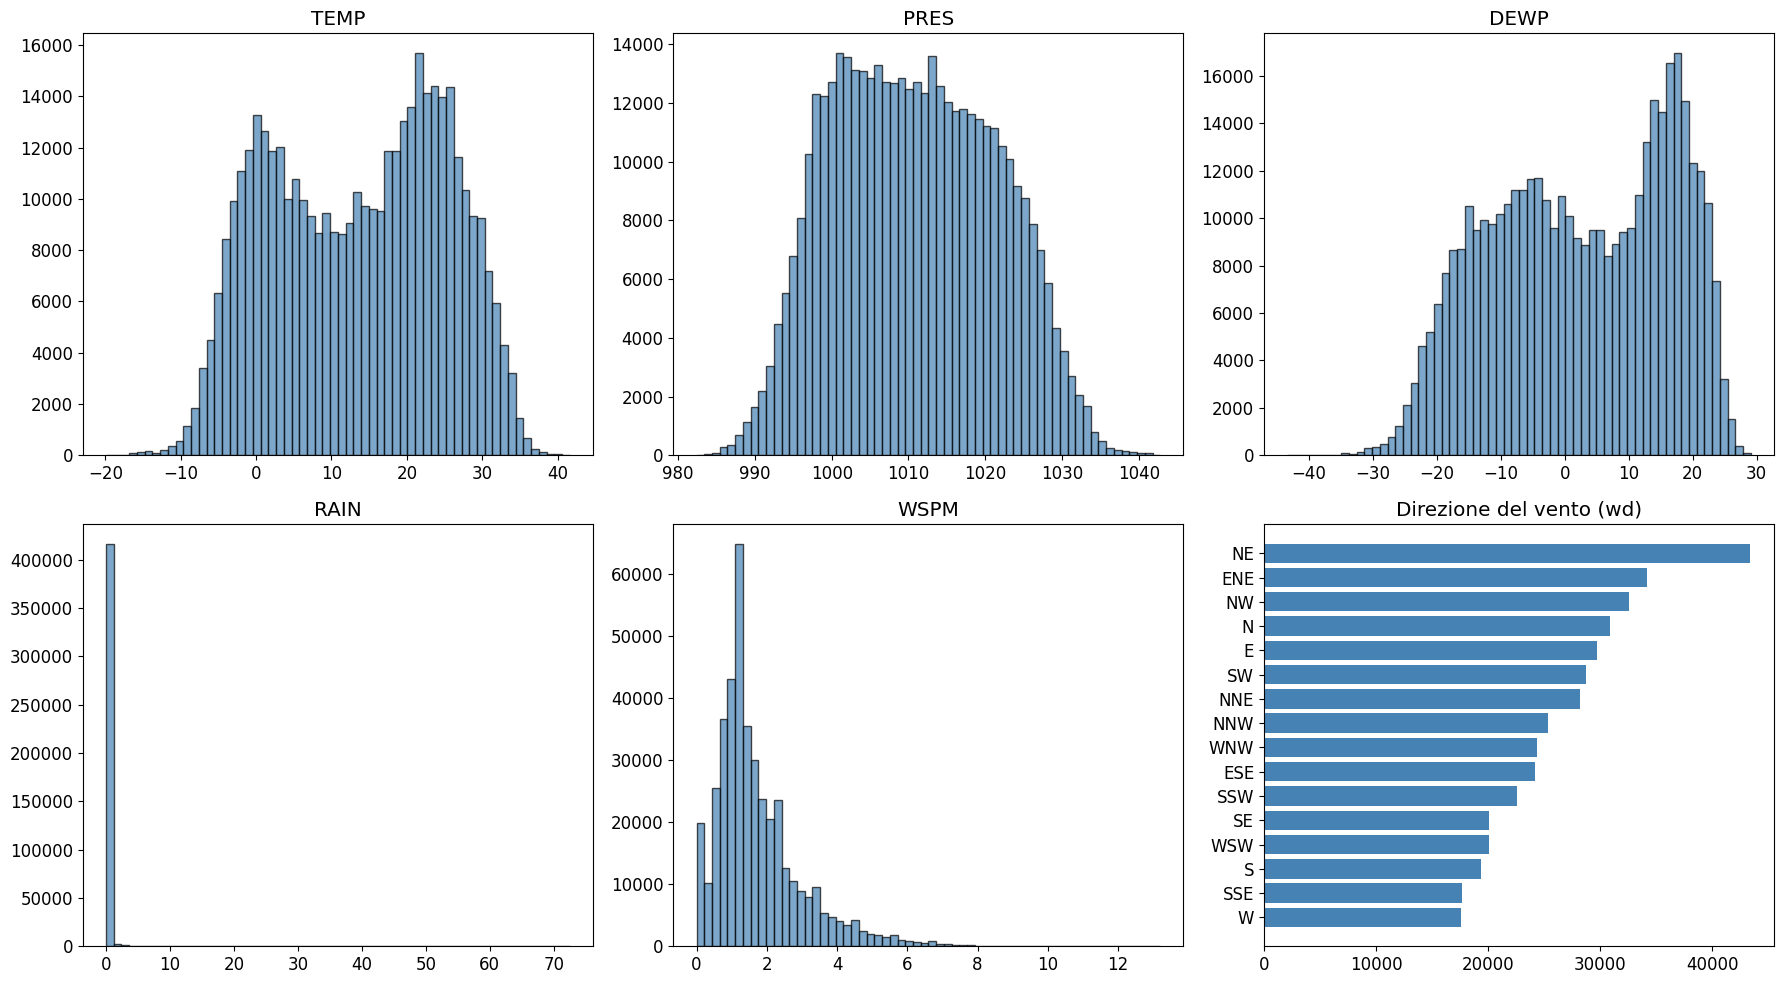

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

meteo_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

for ax, var in zip(axes.flat[:5], meteo_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(var)

wd_counts = df['wd'].value_counts().sort_values(ascending=True)
axes[1,2].barh(wd_counts.index, wd_counts.values, color='steelblue')
axes[1,2].set_title('Direzione del vento (wd)')

plt.tight_layout()
plt.show()

`TEMP` ha un range di circa 60°C (da -20 a +40). `PRES` varia tra 990 e 1040 hPa. `DEWP` ha un range simile a `TEMP`. `RAIN` è quasi esclusivamente a 0: la stragrande maggioranza delle ore ha precipitazione zero. `WSPM` è concentrato a sinistra, con prevalenza di vento debole. La direzione del vento dominante è NE.

### 2.6 Distribuzione degli inquinanti

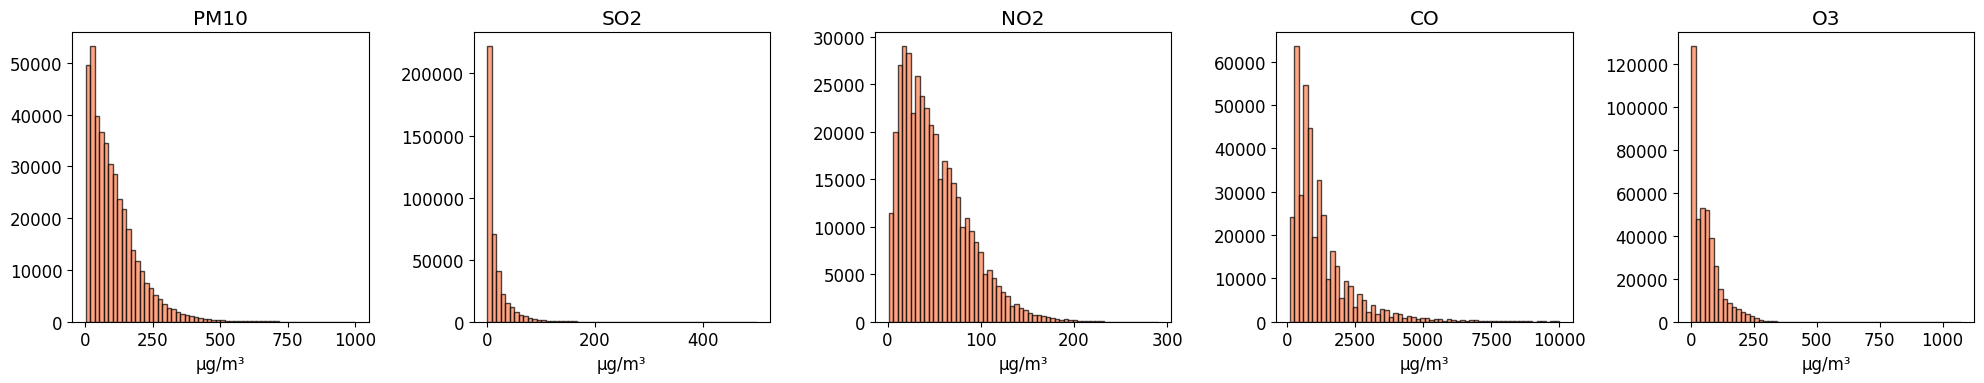

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

poll_vars = ['PM10', 'SO2', 'NO2', 'CO', 'O3']

for ax, var in zip(axes, poll_vars):
    data = df[var].dropna()
    ax.hist(data, bins=60, color='coral', edgecolor='black', alpha=0.7)
    ax.set_title(var)
    ax.set_xlabel('µg/m³')

plt.tight_layout()
plt.show()

Tutti gli inquinanti mostrano una distribuzione concentrata a sinistra, simile a quella del PM2.5.

### 2.7 Analisi per stazione

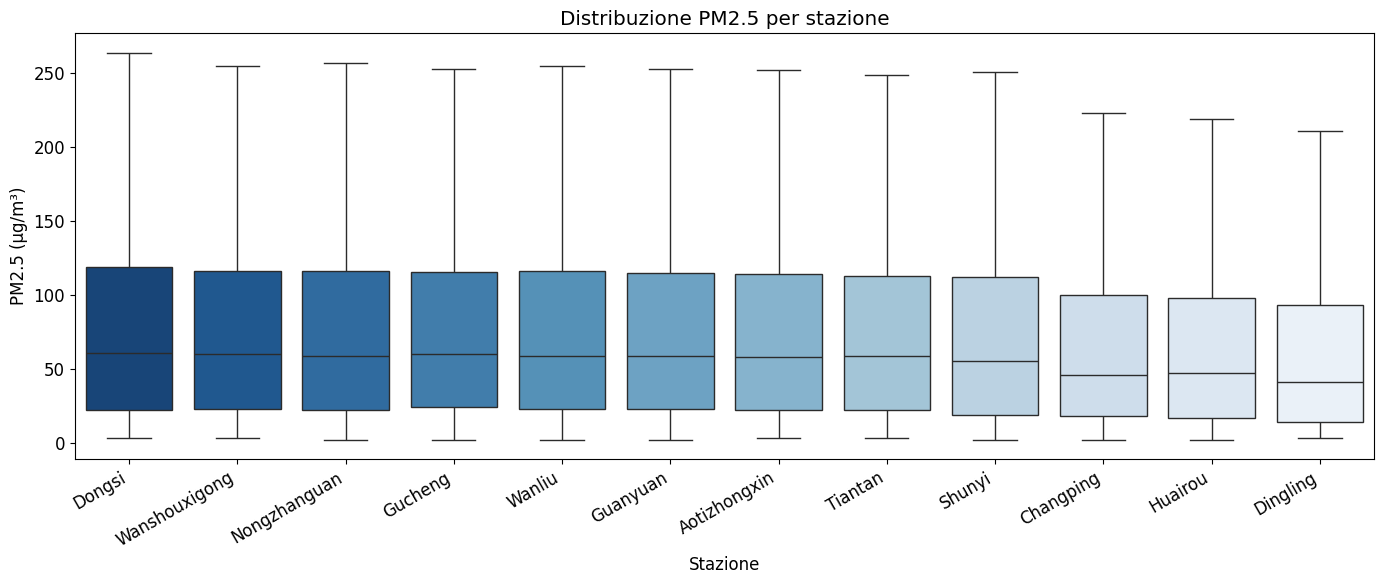

,mean,median,std,count
station,,,,
Dongsi,86.2,61.0,86.6,34314
Wanshouxigong,85.0,60.0,86.0,34368
Nongzhanguan,84.8,59.0,86.2,34436
Gucheng,83.9,60.0,82.8,34418
Wanliu,83.4,59.0,81.9,34682
Guanyuan,82.9,59.0,80.9,34448
Aotizhongxin,82.8,58.0,82.1,34139
Tiantan,82.2,59.0,80.9,34387
Shunyi,79.5,55.0,81.2,34151


In [11]:
station_order = df.groupby('station')['PM2.5'].mean().sort_values(ascending=False).index.tolist()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='station', y='PM2.5', order=station_order, palette='Blues_r', showfliers=False)
plt.title('Distribuzione PM2.5 per stazione')
plt.ylabel('PM2.5 (µg/m³)')
plt.xlabel('Stazione')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

df.groupby('station')['PM2.5'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False).round(1)

Le stazioni hanno valori medi molto simili tra loro: l'inquinamento da PM2.5 è distribuito in modo relativamente uniforme a Pechino. Questo indica che probabilmente la stazione di rilevamento non sarà un predittore importante.

### 2.8 Correlazione tra le feature

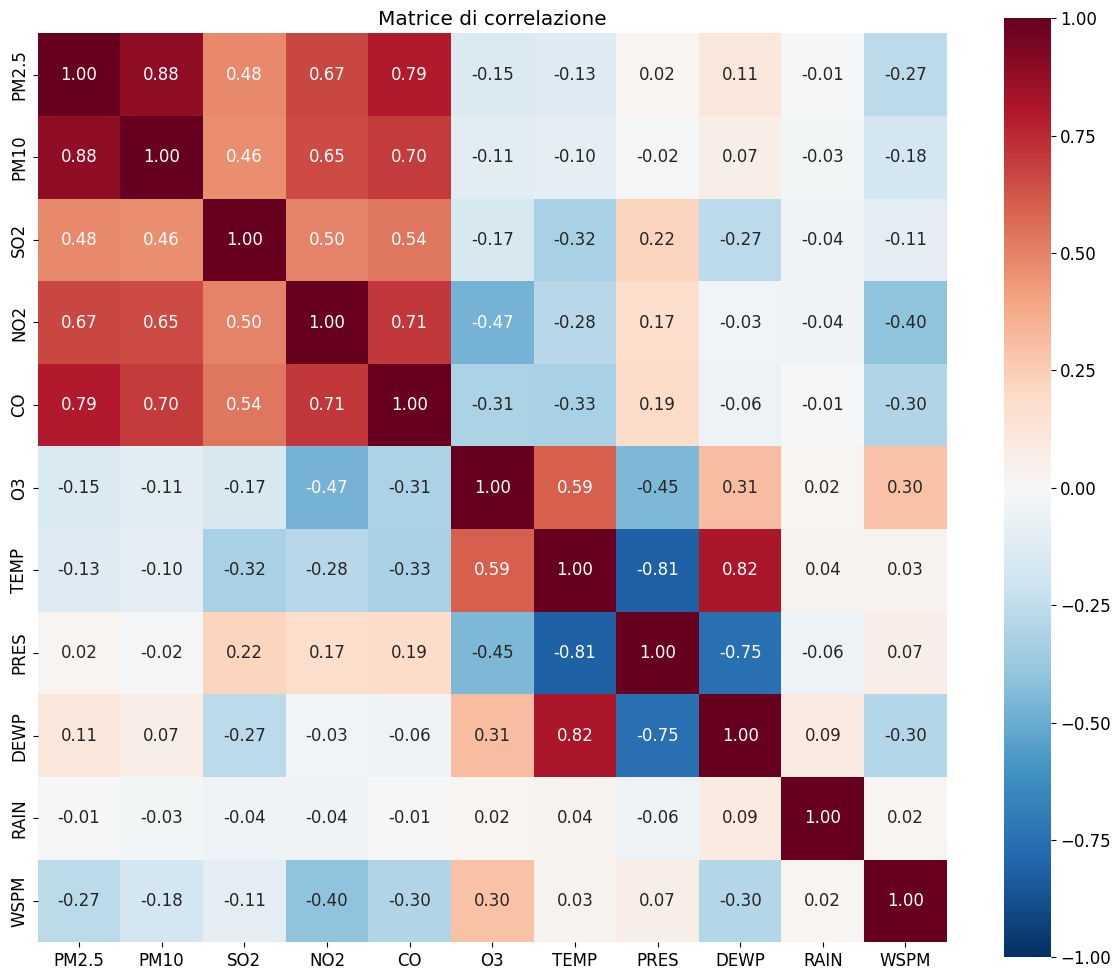

In [12]:


numeric_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', square=True, center=0, vmin=-1, vmax=1)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

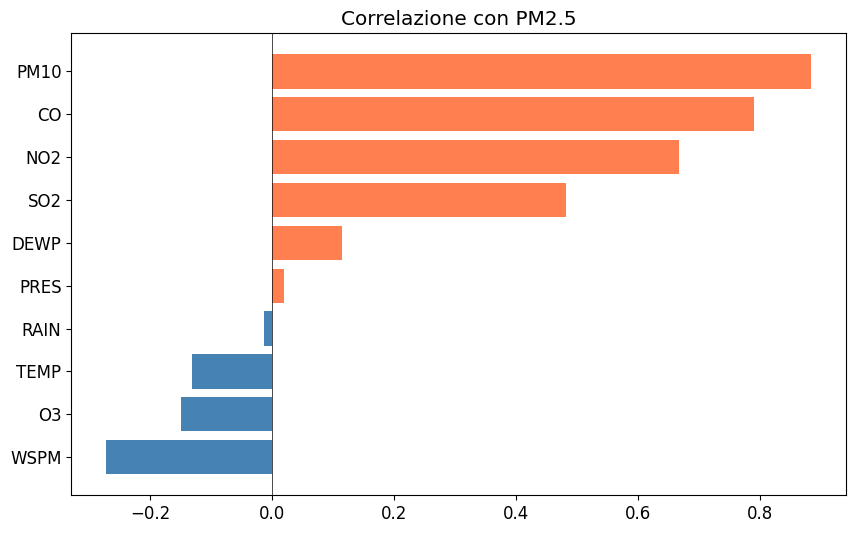

In [13]:
corr_pm25 = corr['PM2.5'].drop('PM2.5').sort_values()

colors = ['steelblue' if v < 0 else 'coral' for v in corr_pm25.values]

plt.figure(figsize=(10, 6))
plt.barh(corr_pm25.index, corr_pm25.values, color=colors)
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Correlazione con PM2.5')
plt.show()

Le correlazioni più forti con il PM2.5 sono:
- `CO` e `PM10` (> 0.7): stesse fonti di emissione, co-emessi con il PM2.5.
- `NO2` e `SO2`: correlazione positiva.
- `O3`: correlazione negativa.
- `WSPM`: negativa, il vento disperde il particolato.
- `TEMP`: negativa, dovuta probabilmente all'effetto dei sistemi di riscaldamento.

### 2.9 Distribuzione di PM2.5 rispetto alle variabili predittive

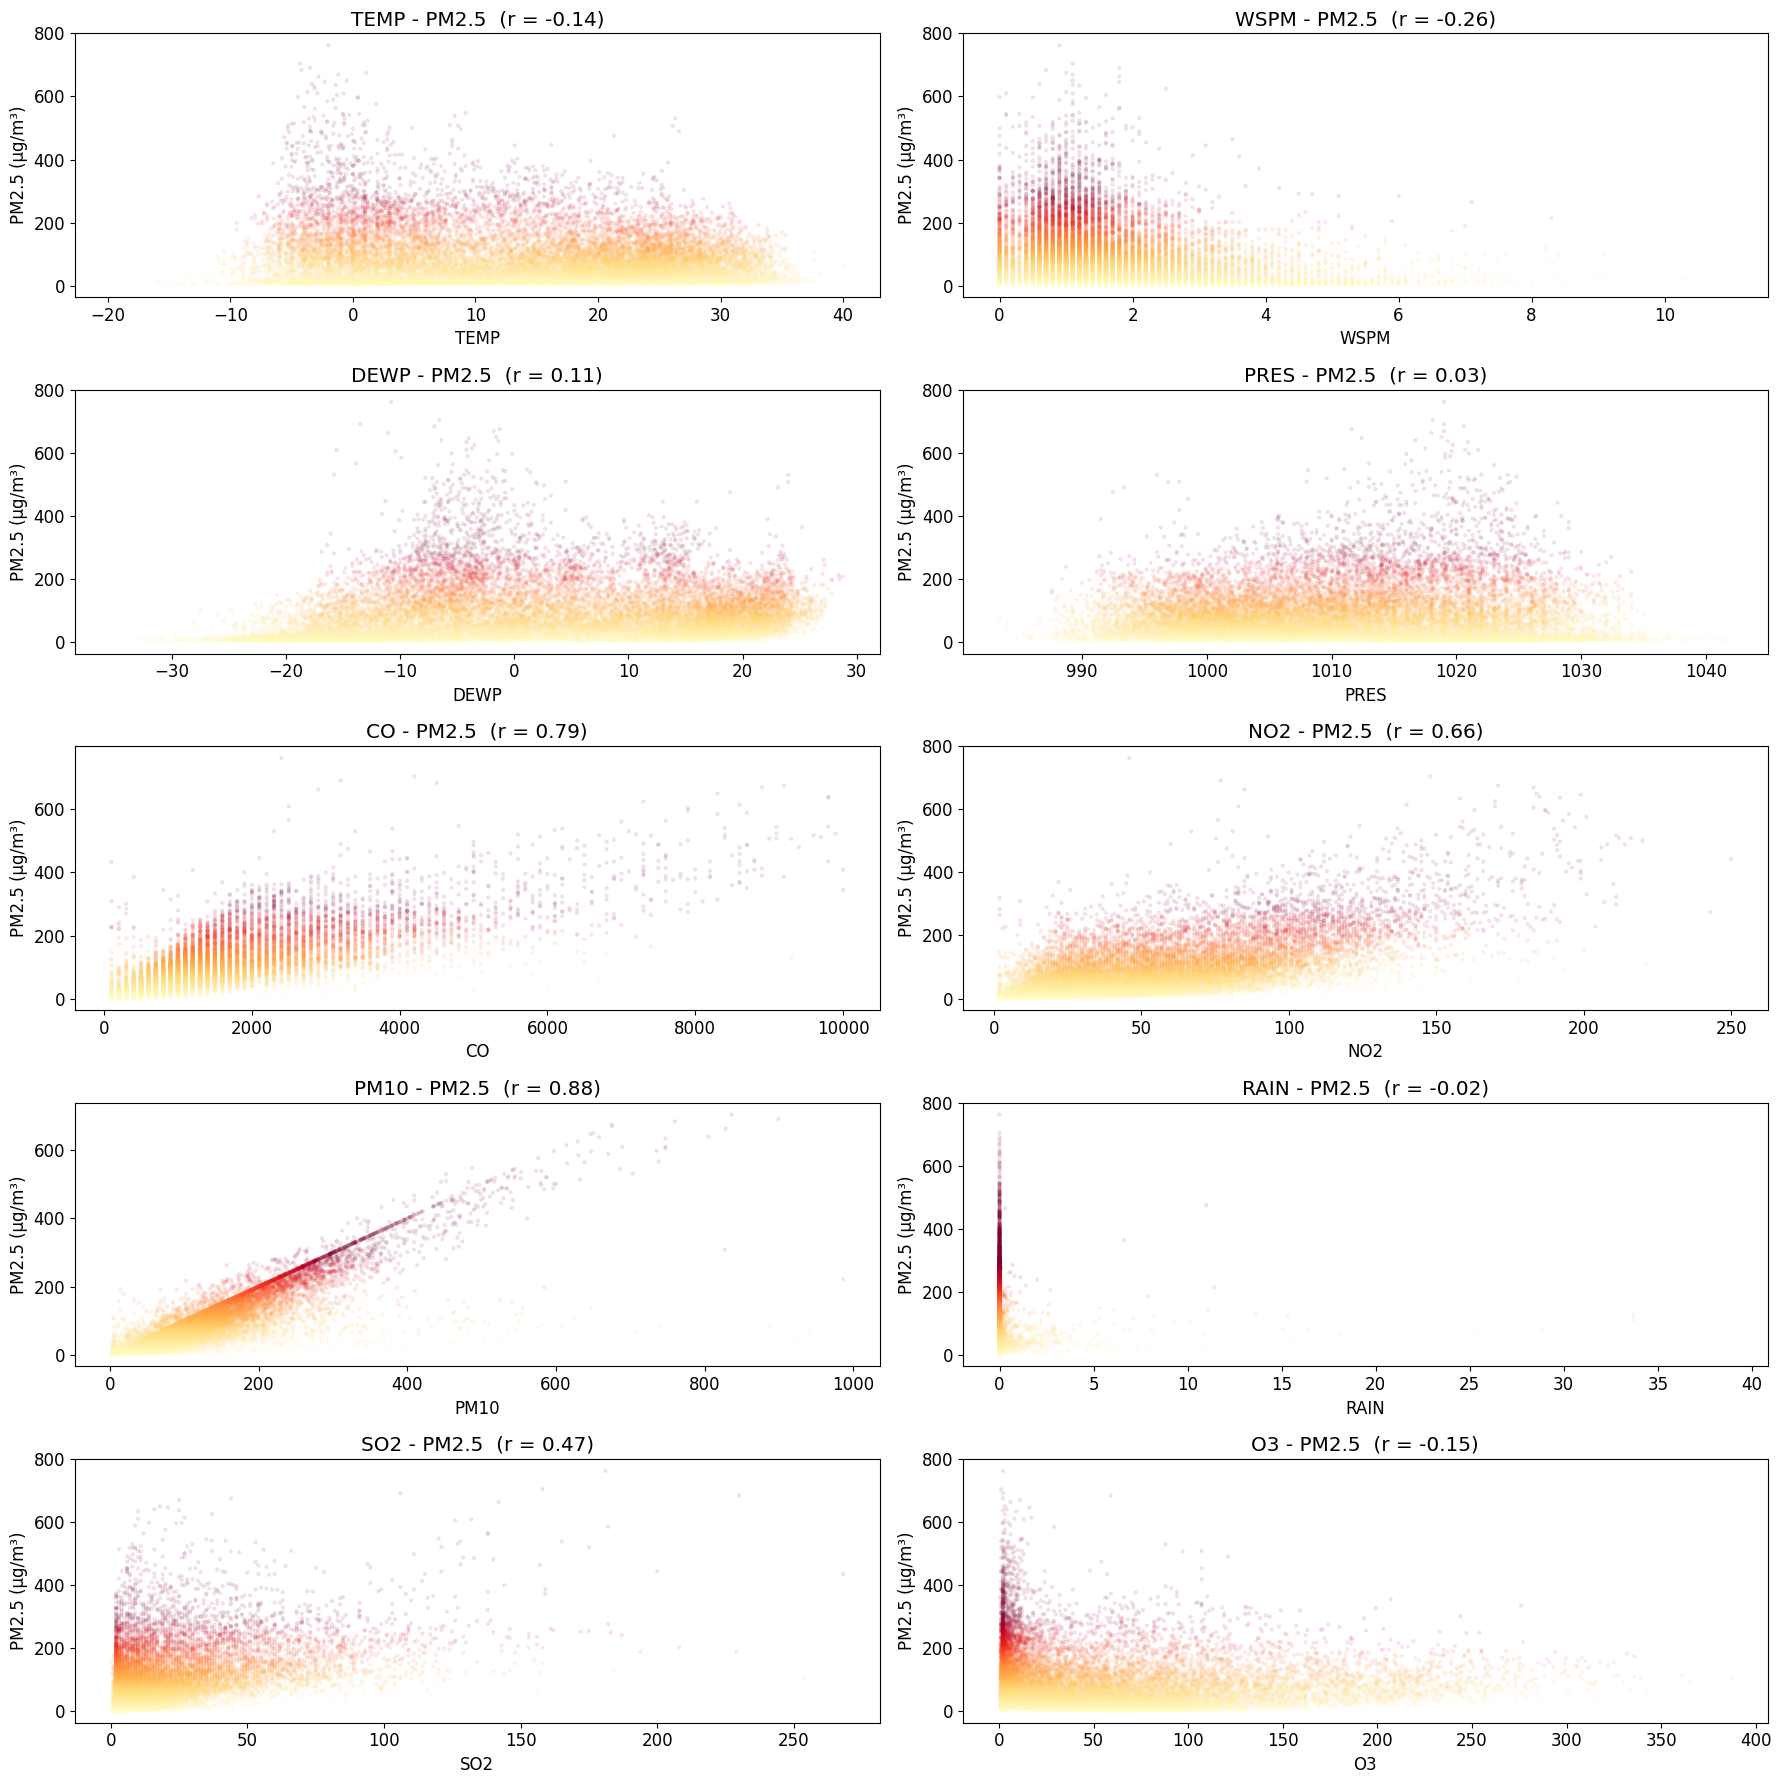

In [14]:
sample = df.dropna(subset=['PM2.5']).sample(n=20000, random_state=SEED)

scatter_vars = ['TEMP', 'WSPM', 'DEWP', 'PRES', 'CO', 'NO2', "PM10", "RAIN", "SO2", "O3"]

fig, axes = plt.subplots(5, 2, figsize=(18, 18))

for ax, var in zip(axes.flat, scatter_vars):
    r = sample['PM2.5'].corr(sample[var])
    sc = ax.scatter(sample[var], sample['PM2.5'], c=sample['PM2.5'], cmap='YlOrRd', alpha=0.08, s=5, vmax=300)
    ax.set_xlabel(var)
    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'{var} - PM2.5  (r = {r:.2f})')

plt.tight_layout()
plt.show()

Tra gli inquinanti, `PM10` risulta il predittore più forte con una correlazione di 0.88: la relazione è quasi lineare, a conferma che i due particolati condividono le stesse sorgenti di emissione. `O3` invece mostra una correlazione negativa (-0.15).

Per le feature meteorologiche, `WSPM` ha la correlazione più forte con il PM2.5 (-0.26): venti forti favoriscono la dispersione del particolato. `TEMP` (-0.13) riflette l'effetto dei sistemi di riscaldamento, mentre `PRES` (0.02) e `RAIN` (0.00) mostrano correlazioni trascurabili.

## 3. Preparazione dei dati

### 3.1 Gestione valori mancanti

I NaN sono causati da guasti dei sensori e rappresentano meno del 5% dei dati. Data la bassa percentuale, vengono rimosse le righe con valori mancanti.

In [15]:
df_model = df.copy()
before = len(df_model)
df_model = df_model.dropna()
after = len(df_model)
print(f"Righe rimosse: {before - after}")
print(f"Righe rimaste: {after}")

Righe rimosse: 38600
Righe rimaste: 382168


### 3.2 Codifica ciclica

Diverse variabili nel dataset sono cicliche: l'ora del giorno, il mese e il giorno della settimana. La codifica numerica normale non rispetta questa periodicità. La trasformazione in sin e cos risolve il problema, mappando ogni valore su una circonferenza dove gli estremi sono adiacenti.

La direzione del vento viene trattata allo stesso modo: essendo una variabile categorica "circolare", la codifica sin/cos preserva la continuità tra direzioni adiacenti.

Si estrae inoltre un flag binario `is_weekend` per distinguere i giorni feriali dai festivi.

In [16]:
# Giorno della settimana e weekend
df_model['dayofweek'] = df_model['datetime'].dt.dayofweek
df_model['is_weekend'] = (df_model['dayofweek'] >= 5).astype(int)

# Codifica ciclica per le variabili temporali
df_model['hour_sin'] = np.sin(2 * np.pi * df_model['hour'] / 24)
df_model['hour_cos'] = np.cos(2 * np.pi * df_model['hour'] / 24)
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)
df_model['dow_sin'] = np.sin(2 * np.pi * df_model['dayofweek'] / 7)
df_model['dow_cos'] = np.cos(2 * np.pi * df_model['dayofweek'] / 7)

# Codifica ciclica per la direzione del vento
wd_to_deg = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}
wd_rad = np.deg2rad(df_model['wd'].map(wd_to_deg))
df_model['wd_sin'] = np.sin(wd_rad)
df_model['wd_cos'] = np.cos(wd_rad)

# Rimozione delle feature originali
df_model.drop(columns=['hour', 'month', 'dayofweek', 'day', 'weekday', 'wd'], inplace=True)

### 3.3 Rimozione valori anomali

Valori di `PM2.5` > 500 µg/m³ corrispondono a eventi eccezionali o a malfunzionamenti dei sensori. Sono rari e possono distorcere i modelli lineari.

In [17]:
before = len(df_model)
df_model = df_model[df_model['PM2.5'] <= 500].reset_index(drop=True)
after = len(df_model)
print(f"Righe rimosse: {before - after:,}")
print(f"Righe rimaste: {after}")

Righe rimosse: 750
Righe rimaste: 381418


### 3.4 Esclusione della feature PM10

`PM10` ha una correlazione di ~0.9 con il `PM2.5` perché questo è fisicamente un sottoinsieme del `PM10`. Includere `PM10` come feature renderebbe la predizione banale: il modello si appoggerebbe quasi interamente su di esso ignorando gli altri predittori.

In [18]:
pm10_saved = df_model['PM10'].copy() # Salvataggio della feature PM10 per una successiva analisi

df_model.drop(columns=['PM10'], inplace=True)

### 3.5 Split temporale

Viene effettuato uno split temporale: il training set comprende i dati fino al 2016-09-01, il test set gli ultimi ~6 mesi. In un problema con struttura temporale, uno split casuale causerebbe data leakage perché il modello vedrebbe dati futuri durante il training.

In [19]:
split_date = pd.Timestamp('2016-09-01')
train_mask = df_model['datetime'] < split_date
test_mask = ~train_mask

print(f"Train: {train_mask.sum()} righe")
print(f"Test:  {test_mask.sum()} righe")

Train: 333282 righe
Test:  48136 righe


### 3.6 Target encoding

Per la stazione viene utilizzato il target encoding: ogni stazione viene sostituita con la media storica del `PM2.5` misurata in quella stazione. La media è calcolata solo sul training set per evitare data leakage.

In [20]:
station_mean = (
    df_model.loc[train_mask]
    .groupby('station')['PM2.5']
    .mean()
)

df_model['station_target_enc'] = df_model['station'].map(station_mean)
df_model.drop(columns=['station'], inplace=True)

### 3.7 Preparazione finale

Il target `PM2.5` viene separato dalle feature predittive. Le colonne `datetime` e `year` vengono rimosse: la prima è una colonna di appoggio non informativa, la seconda è già rappresentata indirettamente dalle feature cicliche del mese.

Il dataset viene infine suddiviso in training e test set rispettando l'ordine temporale, per evitare data leakage.

In [21]:
# Target e feature
y = df_model['PM2.5']

# Rimozione feature non necessarie
X = df_model.drop(columns=['PM2.5', 'datetime', 'year'])

# Split finale
X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

# Salvataggio PM10 per analisi successiva
pm10_train = pm10_saved[train_mask]
pm10_test = pm10_saved[test_mask]

print(f"Righe Train set: {X_train.shape[0]}")
print(f"Righe Test set: {X_test.shape[0]}")
print(f"Feature: {X.shape[1]}\n")

X_train.info(verbose=False, memory_usage='deep')
X_train.head(1)

Righe Train set: 333282
Righe Test set: 48136
Feature: 19

<class 'pandas.core.frame.DataFrame'>
Index: 333282 entries, 0 to 377343
Columns: 19 entries, SO2 to station_target_enc
dtypes: float64(18), int64(1)
memory usage: 50.9 MB


,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM,is_weekend,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,wd_sin,wd_cos,station_target_enc
0,4.0,12.0,200.0,85.0,-0.5,1024.5,-21.4,0.0,5.7,0,0.0,1.0,1.0,6.123234e-17,-0.433884,-0.900969,-0.382683,0.92388,81.382535


## 4. Modelli di Regressione

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = [] # lista dei risultati

tscv = TimeSeriesSplit(n_splits=5) # split temporali per la cross validation

### 4.1 Funzione di valutazione

Viene definita una funzione di valutazione che calcola le principali metriche per la regressione.

In [23]:
def evaluate_model(X, y, model, name=''):
    preds = model.predict(X)
    mse = mean_squared_error(y, preds)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    rel_error = mae / np.mean(y)

    print(f"{name}:")
    print(f"\tRMSE:\t\t\t{rmse:.3f}")
    print(f"\tMAE:\t\t\t{mae:.3f}")
    print(f"\tRelative error:\t\t{rel_error:.3f}")
    print(f"\tR-2 coefficient:\t{r2:.3f}\n")

    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'Relative Error': rel_error, 'R2': r2}

### 4.2 Nested Cross Validation
La nested cross-validation avvolge la ricerca degli iperparametri in un loop esterno di validazione: per ogni fold esterno, la GridSearch viene ri-eseguita indipendentemente sul training set di quel fold e valutata sul fold di test. Il risultato è una stima più affidabile delle performance reali del modello, poiché la selezione degli iperparametri e la valutazione avvengono sempre su dati separati. La deviazione standard indica la stabilità della stima tra i fold.

In [24]:
def nested_cv_score(X, y, search, name=''):
    scores = cross_val_score(search, X, y, cv=tscv, scoring='r2', n_jobs=-1)
    print(f"{name} — Nested CV R²: {scores.mean():.3f} ± {scores.std():.3f}")

### 4.3 DummyRegressor

Il DummyRegressor, predice sempre la media del `PM2.5` calcolata sul training set, ignorando completamente tutte le feature disponibili.

Questo modello non utilizza alcuna informazione predittiva ed è utile come baseline: qualsiasi modello più avanzato deve necessariamente ottenere prestazioni migliori. In questo caso, il valore di R² è circa 0, poiché non spiega alcuna variabilità del target.

In [25]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy='mean')

%time dummy.fit(X_train, y_train)

CPU times: user 425 μs, sys: 116 μs, total: 541 μs
Wall time: 546 μs


DummyRegressor()

In [26]:
evaluate_model(X_train, y_train, dummy, 'DummyRegressor - Train')
results.append(evaluate_model(X_test, y_test, dummy, 'DummyRegressor - Test'))

DummyRegressor - Train:
	RMSE:			74.486
	MAE:			55.918
	Relative error:		0.728
	R-2 coefficient:	0.000

DummyRegressor - Test:
	RMSE:			93.921
	MAE:			69.927
	Relative error:		0.777
	R-2 coefficient:	-0.020



### 4.4 Regressione Lineare

La regressione lineare rappresenta il primo modello “reale”.

Poiché le variabili hanno scale molto diverse, viene utilizzata una Pipeline con StandardScaler per standardizzare i dati prima della regressione. Il modello non include alcuna regolarizzazione, così da valutare la capacità della semplice relazione lineare tra feature e target.

In [27]:
from sklearn.linear_model import LinearRegression

linear = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

nested_cv_score(X_train, y_train, linear, 'Regressione Lineare')
%time linear.fit(X_train, y_train)

Regressione Lineare — Nested CV R²: 0.699 ± 0.013
CPU times: user 235 ms, sys: 99.3 ms, total: 334 ms
Wall time: 208 ms


Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [28]:
evaluate_model(X_train, y_train, linear, 'Regressione Lineare - Train')
results.append(evaluate_model(X_test, y_test, linear, 'Regressione Lineare - Test'))

Regressione Lineare - Train:
	RMSE:			40.001
	MAE:			27.712
	Relative error:		0.361
	R-2 coefficient:	0.712

Regressione Lineare - Test:
	RMSE:			42.725
	MAE:			30.160
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.5 Lasso Regression

Il Lasso aggiunge una penalità L1 ai coefficienti, che può azzerarli completamente effettuando una selezione automatica delle variabili. L'iperparametro alpha controlla l'intensità della regolarizzazione e viene selezionato con GridSearchCV.

In [29]:
from sklearn.linear_model import Lasso

lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso())
])

grid = {'lasso__alpha': [0.1, 0.5, 1]}

gs_lasso = GridSearchCV(lasso, grid, cv=tscv)
nested_cv_score(X_train, y_train, gs_lasso, 'Lasso')
%time gs_lasso.fit(X_train, y_train)

Lasso — Nested CV R²: 0.699 ± 0.011
CPU times: user 10.2 s, sys: 17.9 s, total: 28.1 s
Wall time: 14 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('lasso', Lasso())]),
             param_grid={'lasso__alpha': [0.1, 0.5, 1]})

In [30]:
print(f"Alpha ottimale: {gs_lasso.best_params_['lasso__alpha']}")

evaluate_model(X_train, y_train, gs_lasso, 'Lasso - Train')
results.append(evaluate_model(X_test, y_test, gs_lasso, 'Lasso - Test'))

Alpha ottimale: 0.5
Lasso - Train:
	RMSE:			40.153
	MAE:			27.432
	Relative error:		0.357
	R-2 coefficient:	0.709

Lasso - Test:
	RMSE:			42.521
	MAE:			29.519
	Relative error:		0.328
	R-2 coefficient:	0.791



#### Analisi dei coefficienti di Lasso

In [31]:
coef_lasso = pd.Series(
    gs_lasso.best_estimator_.named_steps['lasso'].coef_,
    index=X_train.columns
)

non_zero = coef_lasso[coef_lasso != 0].sort_values()
zero = coef_lasso[coef_lasso == 0]

print("\nFeature escluse:")
print(zero)


Feature escluse:
TEMP         -0.0
PRES          0.0
is_weekend    0.0
hour_sin      0.0
hour_cos     -0.0
dow_sin      -0.0
wd_sin        0.0
wd_cos       -0.0
dtype: float64


Lasso ha azzerato i coefficienti delle feature `TEMP`, `hour_cos` e `dow_sin`, escludendole dal modello.

### 4.6 Ridge Regression

La Ridge Regression aggiunge una penalità L2 ai coefficienti: li riduce, ma senza azzerarli, per gestire la multicollinearità tra variabili correlate. Anche in questo caso, alpha viene selezionato con GridSearchCV.

In [32]:
from sklearn.linear_model import Ridge

ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [0.1, 1, 10]}

gs_ridge = GridSearchCV(ridge, grid, cv=tscv)
nested_cv_score(X_train, y_train, gs_ridge, 'Ridge')
%time gs_ridge.fit(X_train, y_train)

Ridge — Nested CV R²: 0.699 ± 0.013
CPU times: user 1.85 s, sys: 3.06 s, total: 4.91 s
Wall time: 2.5 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             param_grid={'ridge__alpha': [0.1, 1, 10]})

In [33]:
print(f"Alpha ottimale: {gs_ridge.best_params_['ridge__alpha']}\n")

evaluate_model(X_train, y_train, gs_ridge, 'Ridge - Train')
results.append(evaluate_model(X_test, y_test, gs_ridge, 'Ridge - Test'))

Alpha ottimale: 0.1

Ridge - Train:
	RMSE:			40.001
	MAE:			27.712
	Relative error:		0.361
	R-2 coefficient:	0.712

Ridge - Test:
	RMSE:			42.725
	MAE:			30.160
	Relative error:		0.335
	R-2 coefficient:	0.789



### 4.7 ElasticNet

L'ElasticNet combina le penalità L1 e L2, controllate dagli iperparametri alpha e l1_ratio. Questo permette sia la selezione delle feature (L1) sia la stabilità con variabili correlate (L2).

In [34]:
from sklearn.linear_model import ElasticNet

elasticnet = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', ElasticNet())
])

grid = {
    'regr__alpha': [0.05, 0.1, 0.5],
    'regr__l1_ratio': [0.25, 0.5, 0.75]
}

gs_elasticnet = GridSearchCV(elasticnet, grid, cv=tscv, scoring='r2')
nested_cv_score(X_train, y_train, gs_elasticnet, 'ElasticNet')
%time gs_elasticnet.fit(X_train, y_train)

ElasticNet — Nested CV R²: 0.698 ± 0.012
CPU times: user 25.8 s, sys: 51.2 s, total: 1min 17s
Wall time: 38.6 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('regr', ElasticNet())]),
             param_grid={'regr__alpha': [0.05, 0.1, 0.5],
                         'regr__l1_ratio': [0.25, 0.5, 0.75]},
             scoring='r2')

In [35]:
print(f"Alpha ottimale:    {gs_elasticnet.best_params_['regr__alpha']}")
print(f"L1 ratio ottimale: {gs_elasticnet.best_params_['regr__l1_ratio']}\n")

evaluate_model(X_train, y_train, gs_elasticnet, 'Elastic Net - Train')
results.append(evaluate_model(X_test, y_test, gs_elasticnet, 'Elastic Net - Test'))

Alpha ottimale:    0.05
L1 ratio ottimale: 0.75

Elastic Net - Train:
	RMSE:			40.071
	MAE:			27.501
	Relative error:		0.358
	R-2 coefficient:	0.711

Elastic Net - Test:
	RMSE:			42.423
	MAE:			29.575
	Relative error:		0.329
	R-2 coefficient:	0.792



### 4.8 Regressione Polinomiale

La regressione polinomiale espande le feature con termini quadratici e prodotti tra coppie di variabili, permettendo di catturare relazioni non lineari. Si combina con Ridge per regolarizzare i coefficienti aggiuntivi e ridurre l'overfitting.

In [36]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

poly_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

grid = {'ridge__alpha': [100, 250, 500]}

gs_poly = GridSearchCV(poly_ridge, grid, cv=tscv, scoring='r2', n_jobs=-1)
nested_cv_score(X_train, y_train, linear, 'Regressione Polinomiale')
%time gs_poly.fit(X_train, y_train)

Regressione Polinomiale — Nested CV R²: 0.699 ± 0.013
CPU times: user 1.55 s, sys: 129 ms, total: 1.68 s
Wall time: 7.69 s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('poly',
                                        PolynomialFeatures(include_bias=False)),
                                       ('ridge', Ridge())]),
             n_jobs=-1, param_grid={'ridge__alpha': [100, 250, 500]},
             scoring='r2')

In [37]:
print(f"Alpha ottimale: {gs_poly.best_params_['ridge__alpha']}")

evaluate_model(X_train, y_train, gs_poly, 'Polinomiale - Train')
results.append(evaluate_model(X_test, y_test, gs_poly, 'Polinomiale - Test'))

Alpha ottimale: 500
Polinomiale - Train:
	RMSE:			34.037
	MAE:			22.661
	Relative error:		0.295
	R-2 coefficient:	0.791

Polinomiale - Test:
	RMSE:			41.777
	MAE:			26.187
	Relative error:		0.291
	R-2 coefficient:	0.798



### 4.9 Random Forest

Il Random Forest combina più alberi decisionali, ognuno addestrato su un sottoinsieme casuale dei dati e delle feature. Cattura relazioni non linearità e interazioni senza bisogno di feature engineering esplicito.

In [38]:
from sklearn.ensemble import RandomForestRegressor

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regr', RandomForestRegressor(random_state=SEED, n_jobs=-1))
])

param_dist = {
    'regr__n_estimators':      [200, 300],
    'regr__max_depth':         [8, 10, 12, 15],
    'regr__min_samples_split': [5, 10, 15],
    'regr__min_samples_leaf':  [5, 10, 15],
    'regr__max_features':      ['sqrt'],
    'regr__max_samples':       [0.5, 0.6, 0.7],
}

rs_rf = RandomizedSearchCV(rf, param_dist, n_iter=20, cv=tscv, scoring='r2', random_state=SEED, n_jobs=-1)
nested_cv_score(X_train, y_train, rs_rf, 'Random Forest')
%time rs_rf.fit(X_train, y_train)

Random Forest — Nested CV R²: 0.821 ± 0.025
CPU times: user 1min 32s, sys: 830 ms, total: 1min 33s
Wall time: 24min 16s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('regr',
                                              RandomForestRegressor(n_jobs=-1,
                                                                    random_state=42))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'regr__max_depth': [8, 10, 12, 15],
                                        'regr__max_features': ['sqrt'],
                                        'regr__max_samples': [0.5, 0.6, 0.7],
                                        'regr__min_samples_leaf': [5, 10, 15],
                                        'regr__min_samples_split': [5, 10, 15],
                                        'regr__n_estimators': [200, 300]},
                   random_state=42, scoring='r2')

In [39]:
print(f"Migliori iperparametri: {rs_rf.best_params_}\n")

evaluate_model(X_train, y_train, rs_rf, 'Random Forest - Train')
results.append(evaluate_model(X_test, y_test, rs_rf, 'Random Forest - Test'))

Migliori iperparametri: {'regr__n_estimators': 300, 'regr__min_samples_split': 10, 'regr__min_samples_leaf': 5, 'regr__max_samples': 0.7, 'regr__max_features': 'sqrt', 'regr__max_depth': 15}

Random Forest - Train:
	RMSE:			24.269
	MAE:			15.993
	Relative error:		0.208
	R-2 coefficient:	0.894

Random Forest - Test:
	RMSE:			38.846
	MAE:			23.872
	Relative error:		0.265
	R-2 coefficient:	0.825



### 4.10 XGBoost

XGBoost è un algoritmo di gradient boosting che costruisce alberi in sequenza, dove ogni albero corregge gli errori del precedente. È generalmente il modello più performante per dati tabulari. Si usa RandomizedSearchCV dato il maggior numero di iperparametri.

In [40]:
from xgboost import XGBRegressor

xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(
        random_state=SEED,
        n_jobs=-1,
        tree_method='hist',
    ))
])

param_dist = {
    'xgb__max_depth':        [5, 6, 7],
    'xgb__learning_rate':    [0.03, 0.05, 0.08],
    'xgb__subsample':        [0.5, 0.6, 0.7],
    'xgb__colsample_bytree': [0.6, 0.7, 0.8],
    'xgb__reg_alpha':        [10, 20, 30],
    'xgb__reg_lambda':       [50, 100, 200],
    'xgb__min_child_weight': [40, 50, 60],
    'xgb__gamma':            [5, 10, 15],
    'xgb__n_estimators':     [550, 600, 650]
}

rs_xgb = RandomizedSearchCV(xgb, param_dist, n_iter=20, cv=tscv, scoring='r2', random_state=SEED, n_jobs=-1)
nested_cv_score(X_train, y_train, rs_xgb, 'XGBoost')
%time rs_xgb.fit(X_train, y_train)

XGBoost — Nested CV R²: 0.844 ± 0.022
CPU times: user 14.9 s, sys: 0 ns, total: 14.9 s
Wall time: 5min 42s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('xgb',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           colsample_bylevel=None,
                                                           colsample_bynode=None,
                                                           colsample_bytree=None,
                                                           device=None,
                                                           early_stopping_rounds=None,
                                                           enable_categorical=False,
                                                           eval_metri...
                   n_iter=20, n_jobs=-1,
                   param_distributions={'xgb__colsample_bytree': [0.6, 0.7,
                                                                  0.8],
                                        'xgb__gamma': [5, 10, 15],
                                        'xgb__learning_rate': [0.03, 0.05,
                                                               0.08],
                                        'xgb__max_depth': [5, 6, 7],
                                        'xgb__min_child_weight': [40, 50, 60],
                                        'xgb__n_estimators': [550, 600, 650],
                                        'xgb__reg_alpha': [10, 20, 30],
                                        'xgb__reg_lambda': [50, 100, 200],
                                        'xgb__subsample': [0.5, 0.6, 0.7]},
                   random_state=42, scoring='r2')

In [41]:
print(f"Migliori iperparametri: {rs_xgb.best_params_}\n")

evaluate_model(X_train, y_train, rs_xgb, 'XGBoost - Train')
results.append(evaluate_model(X_test, y_test, rs_xgb, 'XGBoost - Test'))

Migliori iperparametri: {'xgb__subsample': 0.5, 'xgb__reg_lambda': 100, 'xgb__reg_alpha': 30, 'xgb__n_estimators': 550, 'xgb__min_child_weight': 50, 'xgb__max_depth': 7, 'xgb__learning_rate': 0.08, 'xgb__gamma': 15, 'xgb__colsample_bytree': 0.6}

XGBoost - Train:
	RMSE:			23.158
	MAE:			15.264
	Relative error:		0.199
	R-2 coefficient:	0.903

XGBoost - Test:
	RMSE:			38.941
	MAE:			23.815
	Relative error:		0.265
	R-2 coefficient:	0.825



### 4.11 Confronto

In [42]:
results_df = pd.DataFrame(results)
results_df = results_df.set_index('model')
results_df = results_df.round(3)
results_df.sort_values('R2', ascending=False)

,RMSE,MAE,Relative Error,R2
model,,,,
Random Forest - Test,38.846,23.872,0.265,0.825
XGBoost - Test,38.941,23.815,0.265,0.825
Polinomiale - Test,41.777,26.187,0.291,0.798
Elastic Net - Test,42.423,29.575,0.329,0.792
Lasso - Test,42.521,29.519,0.328,0.791
Regressione Lineare - Test,42.725,30.160,0.335,0.789
Ridge - Test,42.725,30.160,0.335,0.789
DummyRegressor - Test,93.921,69.927,0.777,-0.020


La tabella riassume le performance dei modelli di regressione sul test set, ordinati per R².

Random Forest e XGBoost ottengono risultati praticamente identici (R² = 0.825). La regressione polinomiale (R² = 0.798) migliora leggermente rispetto ai modelli lineari.

Tra i modelli lineari le differenze sono minime: ElasticNet (R² = 0.792), Lasso (R² = 0.791) e Ridge coincidono quasi esattamente con la regressione lineare base (R² = 0.789), indicando che la regolarizzazione non porta vantaggi significativi su questo dataset.

## 5. Analisi e interpretazione dei modelli

In questa sezione viene analizzato nel dettaglio un modello per ciascuna categoria: ElasticNet per i modelli lineari, la regressione polinomiale e Random Forest per i modelli ad albero. Per i primi due si esaminano i coefficienti delle feature, mentre per Random Forest si analizza la struttura dei primi nodi, con l'obiettivo di individuare le variabili più rilevanti nella predizione del `PM2.5`.

### 5.1 Coefficienti della regressione lineare (ElasticNet)

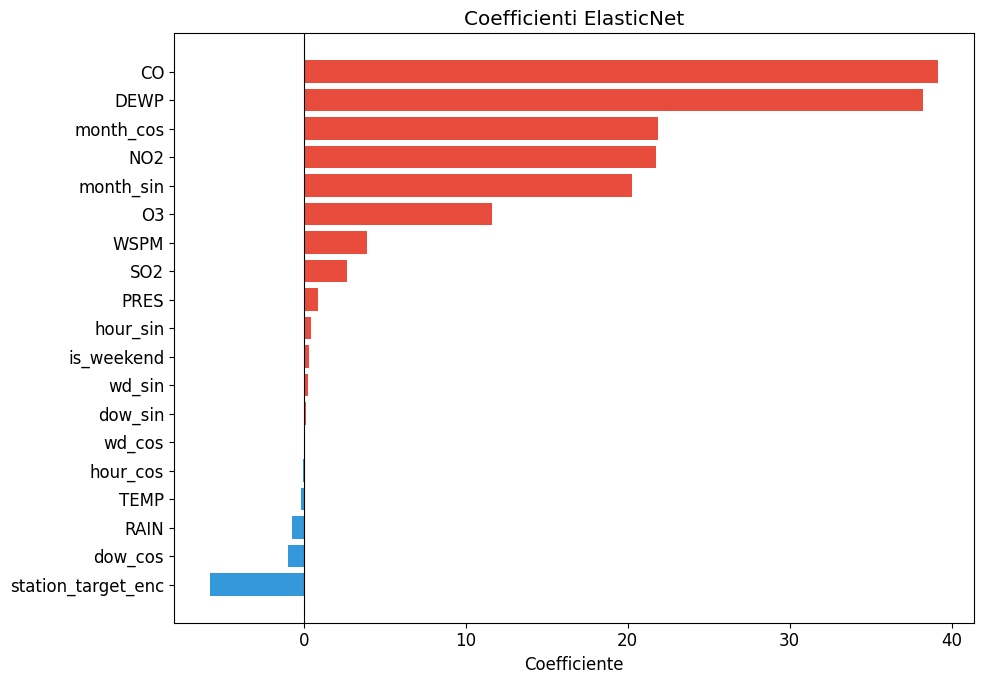

feature più positive:
CO           39.140024
DEWP         38.209821
month_cos    21.855472
NO2          21.718837
month_sin    20.280968
dtype: float64

feature più negative:
station_target_enc   -5.769659
dow_cos              -0.986967
RAIN                 -0.697896
TEMP                 -0.194909
hour_cos             -0.024211
dtype: float64


In [43]:
coef = pd.Series(
    gs_elasticnet.best_estimator_['regr'].coef_,
    index=X_train.columns
).sort_values()

colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef]

plt.figure(figsize=(10, 7))
plt.barh(coef.index, coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coefficienti ElasticNet')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

print(f"Feature più positive:\n{coef.tail(5)[::-1]}\n")
print(f"Feature più negative:\n{coef.head(5)}")

Tra i coefficienti positivi, `CO` e `DEWP` sono i più influenti, seguiti da `NO2` e dalle componenti cicliche del mese (`month_sin`, `month_cos`), che confermano la forte stagionalità del `PM2.5` osservata nell'analisi del dataset. 

Per le feature con coefficiente negativo, `station_target_enc` ha il coefficiente più grande in valore assoluto (-5.6), indicando che stazioni con una media storica di `PM2.5` più alta tendono a predire valori più bassi nel modello lineare. `TEMP` e `RAIN` mostrano coefficienti negativi contenuti.

### 5.2 Coefficienti della regressione polinomiale

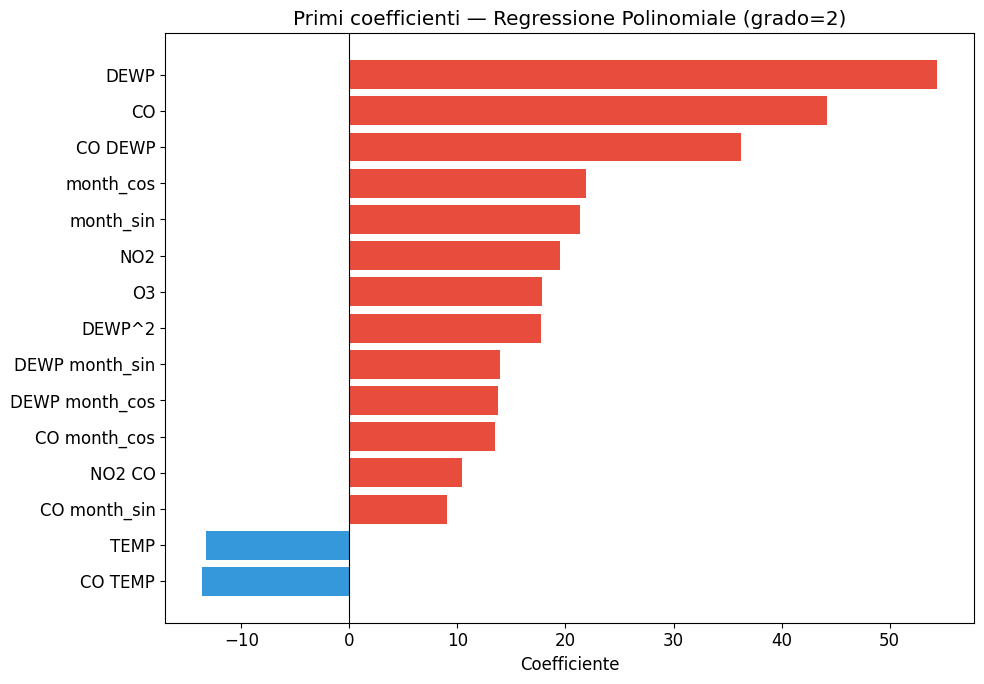

Numero totale di feature polinomiali: 209

feature più positive:
DEWP         54.414344
CO           44.192603
CO DEWP      36.224319
month_cos    21.906367
month_sin    21.368473
dtype: float64

feature più negative:
CO TEMP     -13.661776
TEMP        -13.244025
CO^2         -6.842794
TEMP PRES    -6.813093
SO2 DEWP     -6.482986
dtype: float64


In [44]:
poly_features = gs_poly.best_estimator_['poly'].get_feature_names_out(X_train.columns)
coef_poly = pd.Series(
    gs_poly.best_estimator_['ridge'].coef_,
    index=poly_features
)

top15 = coef_poly.abs().sort_values(ascending=False).head(15)
top15_coef = coef_poly[top15.index].sort_values()
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top15_coef]

plt.figure(figsize=(10, 7))
plt.barh(top15_coef.index, top15_coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Primi coefficienti — Regressione Polinomiale (grado=2)')
plt.xlabel('Coefficiente')
plt.tight_layout()
plt.show()

print(f"Numero totale di feature polinomiali: {len(poly_features)}")
print(f"\nFeature più positive:\n{coef_poly.sort_values().tail(5)[::-1]}")
print(f"\nFeature più negative:\n{coef_poly.sort_values().head(5)}")

La regressione polinomiale di grado 2 genera 209 feature a partire dalle 19 originali, includendo termini quadratici e interazioni tra coppie di variabili.

Tra i coefficienti più rilevanti emergono `DEWP` e `CO` come variabili singole più influenti. Per i termini di interazione, `CO×DEWP` ha il terzo coefficiente più alto, suggerendo che la combinazione di alta concentrazione di `CO` e alto punto di rugiada amplifica il `PM2.5` in modo non lineare. Analogamente, le interazioni `CO×month_sin` e `DEWP×month_sin` catturano l'effetto stagionale combinato con gli inquinanti.

Per i coefficienti negativi, `TEMP` e `CO×TEMP` hanno i coefficienti più grandi in valore assoluto: temperature elevate associate ad alte concentrazioni di `CO` tendono a ridurre il `PM2.5` stimato, probabilmente per effetto della convezione termica che favorisce la dispersione del particolato.

### 5.3 Analisi Random Forest

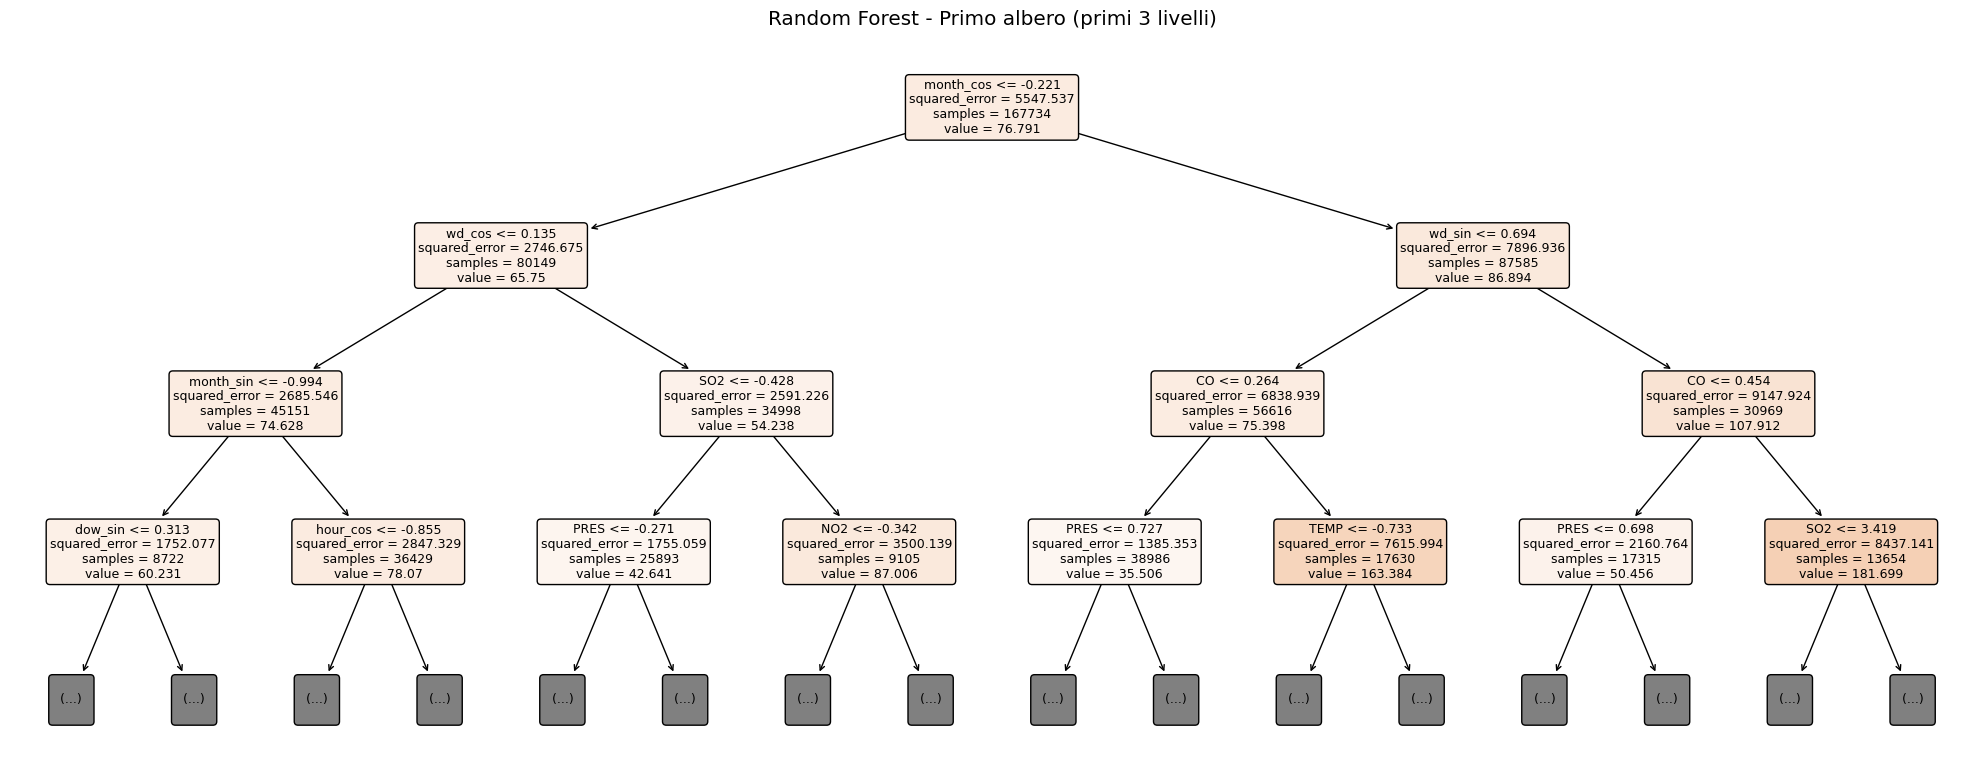

In [45]:
from sklearn.tree import plot_tree

singolo_albero = rs_rf.best_estimator_['regr'].estimators_[0]

plt.figure(figsize=(20, 8))
plot_tree(
    singolo_albero,
    max_depth=3,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Random Forest - Primo albero (primi 3 livelli)')
plt.tight_layout()
plt.show()

Il primo albero del Random Forest effettua il primo split su `month_cos`, separando i mesi con bassa stagionalità invernale da quelli con alta, confermando la forte componente stagionale già osservata nell'analisi del dataset.

Al secondo livello entrambi i rami utilizzano la direzione del vento (`wd_cos` e `wd_sin`), suggerendo che la provenienza delle masse d'aria è un fattore discriminante dopo la stagionalità. Al terzo livello emergono `month_sin`, `SO2` e `CO`.

Si tratta comunque di un singolo albero su centinaia: le variabili scelte e le soglie variano da albero ad albero, ed è la combinazione di tutti che determina la predizione finale del modello.

## 6. Analisi del contributo dei gruppi di feature

In alcuni scenari reali può capitare di non disporre delle misurazioni degli inquinanti chimici, ad esempio in aree prive di sensori dedicati. Per valutare quanto sia possibile predire il PM2.5 in queste condizioni, si addestra XGBoost separatamente su tre gruppi di feature, mantenendo fissi gli iperparametri trovati nella sezione 4.10.

I gruppi sono:
- **Inquinanti**: `SO2`, `NO2`, `CO`, `O3`
- **Temporali + Meteorologiche**: `TEMP`, `PRES`, `DEWP`, `RAIN`, `WSPM`, `wd` e le feature temporali cicliche
- **Tutte + PM10**: tutte le feature precedenti più `PM10`, escluso nella sezione 3.4 per evitare la banalità della predizione. Viene reintegrato qui per quantificarne il contributo.

In [46]:
from sklearn.base import clone

X_train_pm10 = pd.concat([X_train, pm10_train.rename('PM10')], axis=1)
X_test_pm10  = pd.concat([X_test,  pm10_test.rename('PM10')],  axis=1)

feature_groups = {
    'Inquinanti': ['SO2', 'NO2', 'CO', 'O3'],
    'Temporali + Meteorologiche': ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
                                   'wd_sin', 'wd_cos', 'hour_sin', 'hour_cos',
                                   'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
                                   'is_weekend'],
    'Tutte + PM10': X_train_pm10.columns.tolist()
}

for group_name, features in feature_groups.items():
    X_tr = X_train_pm10 if group_name == 'Tutte + PM10' else X_train
    X_te = X_test_pm10  if group_name == 'Tutte + PM10' else X_test
    
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', clone(rs_xgb.best_estimator_['xgb'])) # iperparametri riutilizzati
    ])
    
    model.fit(X_tr[features], y_train)
    
    evaluate_model(X_tr[features], y_train, model, f'XGBoost - {group_name} - Train')
    evaluate_model(X_te[features], y_test, model, f'XGBoost - {group_name} - Test')

XGBoost - Inquinanti - Train:
	RMSE:			37.849
	MAE:			25.210
	Relative error:		0.328
	R-2 coefficient:	0.742

XGBoost - Inquinanti - Test:
	RMSE:			43.064
	MAE:			28.312
	Relative error:		0.315
	R-2 coefficient:	0.786

XGBoost - Temporali + Meteorologiche - Train:
	RMSE:			39.016
	MAE:			26.822
	Relative error:		0.349
	R-2 coefficient:	0.726

XGBoost - Temporali + Meteorologiche - Test:
	RMSE:			64.255
	MAE:			45.635
	Relative error:		0.507
	R-2 coefficient:	0.523

XGBoost - Tutte + PM10 - Train:
	RMSE:			15.949
	MAE:			10.349
	Relative error:		0.135
	R-2 coefficient:	0.954

XGBoost - Tutte + PM10 - Test:
	RMSE:			20.193
	MAE:			12.676
	Relative error:		0.141
	R-2 coefficient:	0.953



I risultati confermano l'importanza relativa dei diversi gruppi di feature.

Il gruppo degli inquinanti (R² = 0.789 sul test) performa meglio del gruppo temporale e meteorologico (R² = 0.545), confermando che `CO`, `NO2`, `SO2` e `O3` sono i predittori più informativi. Il gruppo meteorologico ottiene comunque un discreto risultato: in assenza di sensori chimici è quindi possibile stimare il PM2.5 con una certa approssimazione basandosi solo su temperatura, umidità e stagionalità.

Il modello con tutte le feature più `PM10` raggiunge R² = 0.951, confermando quanto già osservato nell'analisi esplorativa (r = 0.88): `PM10` è il predittore più potente per il `PM2.5`, motivo per cui era stato escluso per evitare che dominasse il modello a scapito delle altre variabili.

## 7. Classificazione
In un sistema di allerta per la qualità dell'aria non è sempre necessario conoscere il valore esatto di `PM2.5`, ma è sufficiente sapere in quale fascia di rischio rientra. Il problema viene quindi riformulato come classificazione multiclasse, assegnando ad ogni osservazione una delle categorie dello standard AQI cinese in base alla concentrazione di `PM2.5`.


### 7.1 Definizione delle classi e distribuzione
Come già osservato durante l'analisi del dataset, le classi sono fortemente sbilanciate: la maggior parte delle ore rientra nella fascia "Buona" e "Moderata", mentre le classi più pericolose hanno pochi campioni. Per gestire questo sbilanciamento si usa `class_weight='balanced'` nei classificatori, che assegna pesi inversamente proporzionali alla frequenza di ogni classe.

In [47]:
aqi_bins = [0, 35, 75, 115, 150, 250, np.inf]
aqi_names = ['Buona', 'Moderata', 'Leggermente inquinata', 'Moderatamente inquinata', 'Pesantemente inquinata', 'Gravemente inquinata']
aqi_colors = ['#00e400', '#ffff00', '#ff7e00', '#ff0000', '#8f3f97', '#7e0023']
 
# Creazione target classificazione
y_train_class = pd.cut(y_train, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)
y_test_class = pd.cut(y_test, bins=aqi_bins, labels=range(6), include_lowest=True).astype(int)

### 7.2 Funzione di valutazione e Nested Cross Validation
 
Si definisce una funzione unica per valutare i classificatori con accuracy e F1 macro.

In [48]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
 
results_clf = []

tscv = TimeSeriesSplit(n_splits=5)
 
def evaluate_clf(X, y, model, name=''):
    preds = model.predict(X)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, average='macro')

    print(f"{name}:")
    print(f"\tAccuracy:\t{acc:.4f}")
    print(f"\tF1 Macro:\t{f1:.4f}\n")

    return {'model': name, 'Accuracy': acc, 'F1 Macro': f1}

Anche per la classificazione viene utilizzata la Nested Cross Validation.

In [49]:
def nested_cv_score_clf(X, y, search, name=''):
    scores = cross_val_score(search, X, y, cv=tscv, scoring='f1_macro', n_jobs=-1)
    print(f"{name} — Nested CV F1 macro: {scores.mean():.3f} ± {scores.std():.3f}")
    return {'model': name, 'Nested CV F1 mean': scores.mean(), 'Nested CV F1 std': scores.std()}

### 7.3 Logistic Regression
 
La regressione logistica è il modello lineare di riferimento per la classificazione. Viene testata con tre tipi di regolarizzazione (L1, L2 ed ElasticNet) per valutare quale penalizzazione produce la migliore generalizzazione. Il parametro `C` controlla l'intensità della regolarizzazione: valori bassi producono un modello più semplice, valori alti riducono la penalizzazione. Il `class_weight='balanced'` compensa lo sbilanciamento delle classi AQI.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
 
lr_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver="saga", max_iter=5000, class_weight='balanced', random_state=SEED))
])

grid = [
    {
        "clf__penalty":  ["l1", "l2"],
        "clf__C":        [5, 10],
    },
    {
        "clf__penalty":  ["elasticnet"],
        "clf__C":        [5, 10],
        "clf__l1_ratio": [0.2, 0.5],
    },
]
 
gs_lr_clf = GridSearchCV(lr_clf, grid, cv=tscv, scoring='f1_macro', n_jobs=-1)
nested_cv_score_clf(X_train, y_train_class, gs_lr_clf, 'Logistic Regression')
%time gs_lr_clf.fit(X_train, y_train_class)

Logistic Regression — Nested CV F1 macro: 0.492 ± 0.049
CPU times: user 21.1 s, sys: 259 ms, total: 21.4 s
Wall time: 6min 38s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('clf',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=5000,
                                                           random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [5, 10], 'clf__penalty': ['l1', 'l2']},
                         {'clf__C': [5, 10], 'clf__l1_ratio': [0.2, 0.5],
                          'clf__penalty': ['elasticnet']}],
             scoring='f1_macro')

In [51]:
print(f"Penalty ottimale: {gs_lr_clf.best_params_['clf__penalty']}")
print(f"C ottimale:       {gs_lr_clf.best_params_['clf__C']}\n")
if gs_lr_clf.best_params_['clf__penalty'] == 'elasticnet':
    print(f"L1 ratio:         {gs_lr_clf.best_params_['clf__l1_ratio']}\n")

evaluate_clf(X_train, y_train_class, gs_lr_clf, 'Logistic Regression - Train')
results_clf.append(evaluate_clf(X_test, y_test_class, gs_lr_clf, 'Logistic Regression - Test'))

Penalty ottimale: l2
C ottimale:       5
Logistic Regression - Train:
	Accuracy:	0.6106
	F1 Macro:	0.5238

Logistic Regression - Test:
	Accuracy:	0.6115
	F1 Macro:	0.4973



### 7.4 Random Forest Classifier
 
Il Random Forest Classifier combina più alberi decisionali per la classificazione multi-classe. Come nella versione regressiva, `class_weight='balanced'` compensa lo sbilanciamento delle classi e `max_samples=0.3` limita i dati usati per ogni albero per ridurre i tempi di addestramento. La ricerca degli iperparametri esplora profondità e numero di alberi tramite RandomizedSearchCV.

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1,
        max_samples=0.3
    ))
])

param_dist = {
    'clf__n_estimators':      [200, 300],
    'clf__max_depth':         [10, 15],
    'clf__min_samples_split': [10, 20],
    'clf__max_features':      ['sqrt'],
}

rs_rf_clf = RandomizedSearchCV(rf_clf, param_dist, n_iter=8, cv=tscv, scoring='f1_macro', random_state=SEED, n_jobs=-1)
nested_cv_score_clf(X_train, y_train_class, rs_rf_clf, 'Random Forest Classifier')
%time rs_rf_clf.fit(X_train, y_train_class)

Random Forest Classifier — Nested CV F1 macro: 0.623 ± 0.043
CPU times: user 1min 1s, sys: 465 ms, total: 1min 1s
Wall time: 8min


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('clf',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     max_samples=0.3,
                                                                     n_jobs=-1,
                                                                     random_state=42))]),
                   n_iter=8, n_jobs=-1,
                   param_distributions={'clf__max_depth': [10, 15],
                                        'clf__max_features': ['sqrt'],
                                        'clf__min_samples_split': [10, 20],
                                        'clf__n_estimators': [200, 300]},
                   random_state=42, scoring='f1_macro')

In [56]:
print(f"Migliori iperparametri: {rs_rf_clf.best_params_}\n")

evaluate_clf(X_train, y_train_class, rs_rf_clf, 'Random Forest - Train')
results_clf.append(evaluate_clf(X_test, y_test_class, rs_rf_clf, 'Random Forest - Test'))

Migliori iperparametri: {'clf__n_estimators': 300, 'clf__min_samples_split': 10, 'clf__max_features': 'sqrt', 'clf__max_depth': 15}

Random Forest - Train:
	Accuracy:	0.7933
	F1 Macro:	0.7744

Random Forest - Test:
	Accuracy:	0.6447
	F1 Macro:	0.5298



### 7.5 XGBoost Classifier

XGBoost Classifier applica il gradient boosting alla classificazione multi-classe. La ricerca degli iperparametri esplora sia la complessità del modello (profondità degli alberi, numero di stimatori, learning rate) sia i parametri di regolarizzazione (reg_alpha, reg_lambda, gamma, min_child_weight) per ridurre l'overfitting. Lo sbilanciamento delle classi viene gestito indirettamente tramite la metrica `f1_macro` usata nella selezione degli iperparametri.

In [58]:
from xgboost import XGBClassifier

xgb_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        random_state=SEED,
        tree_method='hist',
        n_jobs=-1
    ))
])

param_dist = {
    'clf__n_estimators':     [200, 300],
    'clf__max_depth':        [3, 4, 6],
    'clf__learning_rate':    [0.05, 0.1],
    'clf__subsample':        [0.7, 0.8],
    'clf__colsample_bytree': [0.7, 0.8],
    'clf__reg_alpha':        [0.1, 1],
    'clf__reg_lambda':       [1, 5],
    'clf__min_child_weight': [5, 10, 20],
    'clf__gamma':            [0.1, 0.5, 1],
}

rs_xgb_clf = RandomizedSearchCV(xgb_clf, param_dist, n_iter=20, cv=tscv, scoring='f1_macro', random_state=SEED, n_jobs=1)
nested_cv_score_clf(X_train, y_train_class, rs_xgb_clf, 'XGBoost Classifier')
%time rs_xgb_clf.fit(X_train, y_train_class)

XGBoost Classifier — Nested CV F1 macro: 0.617 ± 0.044
CPU times: user 33min 8s, sys: 11.2 s, total: 33min 19s
Wall time: 16min 56s


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('clf',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metr...
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=1,
                   param_distributions={'clf__colsample_bytree': [0.7, 0.8],
                                        'clf__gamma': [0.1, 0.5, 1],
                                        'clf__learning_rate': [0.05, 0.1],
                                        'clf__max_depth': [3, 4, 6],
                                        'clf__min_child_weight': [5, 10, 20],
                                        'clf__n_estimators': [200, 300],
                                        'clf__reg_alpha': [0.1, 1],
                                        'clf__reg_lambda': [1, 5],
                                        'clf__subsample': [0.7, 0.8]},
                   random_state=42, scoring='f1_macro')

In [60]:
print(f"Migliori iperparametri: {rs_xgb_clf.best_params_}\n")

evaluate_clf(X_train, y_train_class, rs_xgb_clf, 'XGBoost - Train')
results_clf.append(evaluate_clf(X_test, y_test_class, rs_xgb_clf, 'XGBoost - Test'))

Migliori iperparametri: {'clf__subsample': 0.7, 'clf__reg_lambda': 1, 'clf__reg_alpha': 1, 'clf__n_estimators': 300, 'clf__min_child_weight': 10, 'clf__max_depth': 6, 'clf__learning_rate': 0.1, 'clf__gamma': 1, 'clf__colsample_bytree': 0.7}

XGBoost - Train:
	Accuracy:	0.7706
	F1 Macro:	0.7234

XGBoost - Test:
	Accuracy:	0.6609
	F1 Macro:	0.5306



### 7.6 Tabella comparativa classificatori

In [62]:
results_clf_df = pd.DataFrame(results_clf)
results_clf_test = results_clf_df[results_clf_df['model'].str.contains('Test')].copy()
results_clf_test = results_clf_test.sort_values('F1 Macro', ascending=False)
results_clf_test.round(3)

,model,Accuracy,F1 Macro
2,XGBoost - Test,0.661,0.531
1,Random Forest - Test,0.645,0.530
0,Logistic Regression - Test,0.611,0.497


### 7.7 Confusion matrix e analisi errori
 
Si analizza la confusion matrix di XGBoost Classifier per capire dove il modello sbaglia e se gli errori sono "gravi" (classi lontane) o "accettabili" (classi adiacenti).

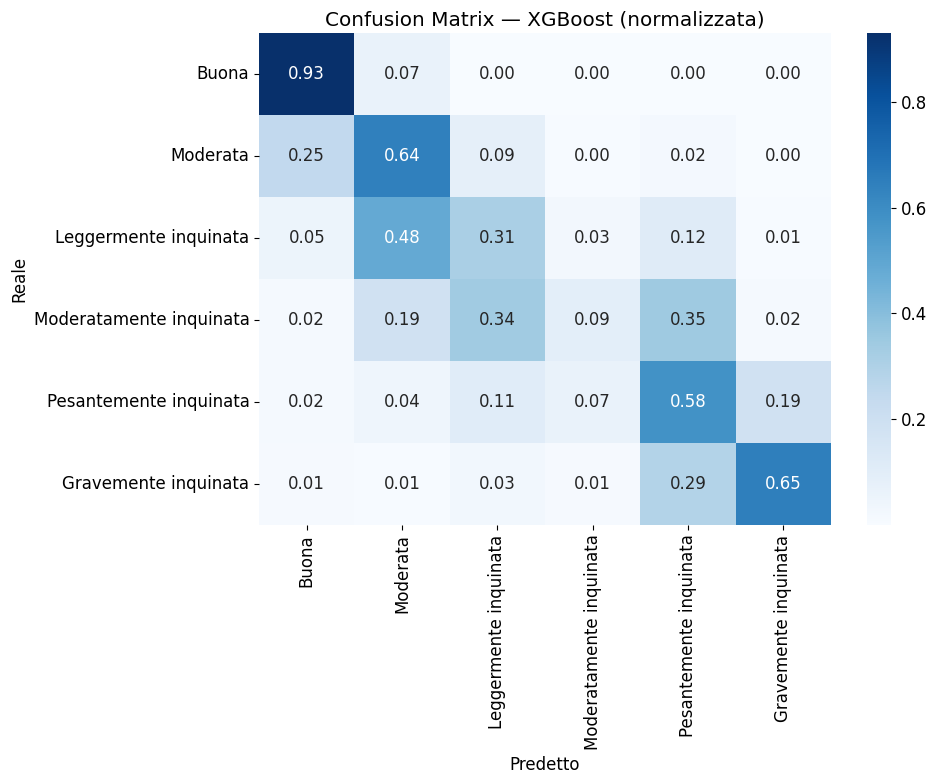


Classification Report — XGBoost:



'                         precision    recall  f1-score   support\n\n                  Buona       0.87      0.93      0.90     19066\n               Moderata       0.50      0.64      0.56      8405\n  Leggermente inquinata       0.39      0.31      0.35      6206\nModeratamente inquinata       0.34      0.09      0.15      4103\n Pesantemente inquinata       0.55      0.58      0.57      7064\n   Gravemente inquinata       0.59      0.65      0.62      3292\n\n               accuracy                           0.66     48136\n              macro avg       0.54      0.53      0.52     48136\n           weighted avg       0.63      0.66      0.64     48136\n'

In [66]:
best_name = "XGBoost"
y_pred_best = rs_xgb_clf.predict(X_test)

cm = confusion_matrix(y_test_class, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=aqi_names, yticklabels=aqi_names, ax=ax)
ax.set_xticklabels(aqi_names, rotation=30, ha='right')
ax.set_xlabel('Predetto')
ax.set_ylabel('Reale')
ax.set_title(f'Confusion Matrix — XGBoost Classifier (normalizzata)')

plt.tight_layout()
plt.show()

print(f"\nClassification Report — XGBoost Classifier:\n")
print(classification_report(y_test_class, y_pred_best, target_names=aqi_names))

La confusion matrix di XGBoost evidenzia un comportamento atteso per un problema multi-classe con dati sbilanciati. Il modello classifica molto bene le classi estreme: "Buona" con recall del 93% e "Gravemente inquinata" con recall del 65%, le due fasce più nette in termini di concentrazione di `PM2.5`.

Le classi intermedie risultano invece più difficili da distinguere, come mostra la diagonale più debole. "Moderatamente inquinata" è la più problematica (recall dell'11%): viene spesso confusa con le classi adiacenti "Leggermente inquinata" e "Pesantemente inquinata". Questo è dovuto alla natura ordinale del problema, dove i confini tra fasce contigue sono basati su soglie arbitrarie di `PM2.5` e le osservazioni vicine ai limiti sono intrinsecamente ambigue. Si nota infatti che gli errori si concentrano quasi sempre nelle celle immediatamente adiacenti alla diagonale, segno che il modello raramente sbaglia di più di una fascia.

Con un'accuracy del 66% e un F1 macro di 0.53, il modello risulta utile come sistema di allerta: identifica con buona affidabilità le situazioni di aria pulita e di inquinamento grave, che sono le più rilevanti dal punto di vista pratico, pur faticando nelle distinzioni più fini tra livelli intermedi.

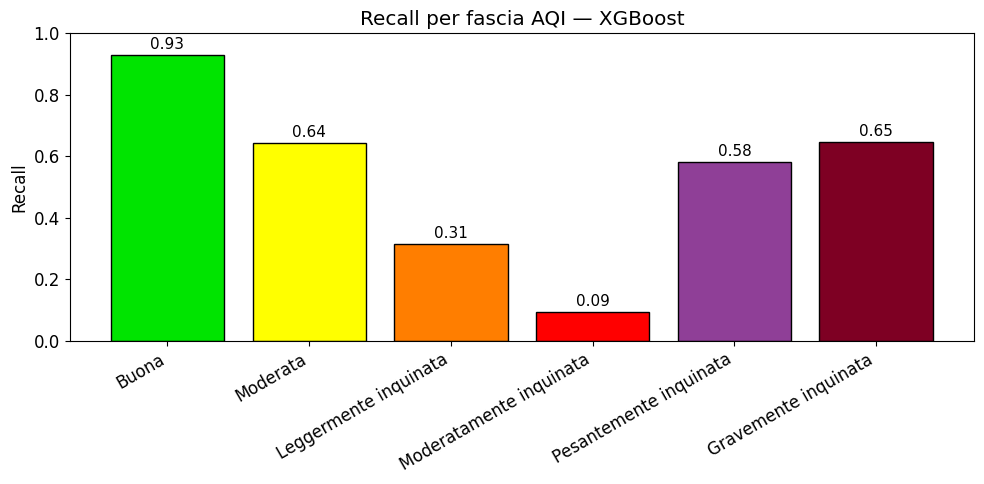

In [68]:
recall_per_class = cm.diagonal() / cm.sum(axis=1)
 
plt.figure(figsize=(10, 5))
bars = plt.bar(aqi_names, recall_per_class, color=aqi_colors, edgecolor='black')
plt.ylabel('Recall')
plt.title(f'Recall per fascia AQI — {best_name}')
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
 
for bar, val in zip(bars, recall_per_class):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.2f}', ha='center', fontsize=11)
 
plt.tight_layout()
plt.show()

Il grafico mostra il recall per ciascuna fascia AQI. La classe "Buona" ottiene il recall più alto (0.93), grazie alla sua abbondanza nel dataset. Le classi estreme di inquinamento ("Pesantemente inquinata" 0.59, "Gravemente inquinata" 0.65) hanno recall discreto nonostante i pochi campioni, merito del `class_weight='balanced'`.

La classe più critica è "Moderatamente inquinata" (0.11): si trova in una posizione intermedia e viene sistematicamente confusa con le fasce adiacenti. In un sistema di allerta reale questo rappresenta il limite principale del modello, poiché una fascia di rischio medio-alta viene spesso non riconosciuta.

## 8. Esportazione del modello di regressione

Per concludere, viene esportato il modello di regressione XGBoost in formato `.pkl` tramite `joblib`, per poterlo caricare e utilizzare nell'applicazione web.

In [62]:
import joblib

joblib.dump(rs_xgb.best_estimator_, 'model_xgb.pkl')

['model_xgb.pkl']